# **E-commerce Sales Analytics | Google BigQuery · Python · Tableau**

## **1. Data Infrastructure & Environment Setup**

### **1.1 Project Overview**

This project focuses on building a full-cycle analytical solution for an e-commerce business.
The objective is to extract transactional and behavioral data from Google BigQuery, perform exploratory and statistical analysis in Python, and build an analytical dashboard in Tableau Public.

The analysis aims to identify key revenue drivers, understand customer behavior, evaluate traffic channels performance, and detect statistical relationships between core business metrics.

### **1.2 Data Source**

The analysis is based on the `DA` dataset located in the `data-analytics-mate` Google BigQuery project.  
The dataset contains session-level, transactional, product, and account-related data.

### **Core Tables Used in the Analysis**

- `session`
- `session_params`
- `order`
- `product`
- `account`
- `account_session`

These tables provide information about user sessions, traffic sources, transactions, products, and registered accounts, which enables comprehensive sales and behavioral analysis.

### **1.3 Environment Setup**

This section imports all required libraries used throughout the analysis, including data processing, visualization, and statistical testing.

In [ ]:
# ===============================
# Data processing
# ===============================
import pandas as pd
import numpy as np

# ===============================
# Visualization
# ===============================
import matplotlib.pyplot as plt

# ===============================
# Statistical analysis
# ===============================
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest

# ===============================
# Google BigQuery library
# ===============================
from google.cloud import bigquery

# ===============================
# Display settings
# ===============================
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

### **1.4 BigQuery Connection**

To perform analytical queries, a connection to Google BigQuery must be established.  
This step ensures access to the `DA` dataset within the `data-analytics-mate` project.

### **Environment Setup**

The following libraries are required to interact with BigQuery and process the data in Python:

- `google-cloud-bigquery`
- `pandas-gbq`
- `pyarrow`

### **Connection Logic**

1. Authenticate the session in Google Colab.
2. Initialize a BigQuery client using the project ID.
3. Validate dataset accessibility by retrieving the list of available tables.

This confirms that the environment is correctly configured and ready for analytical SQL execution.

In [ ]:
# ===============================
# Google Colab authentication
# ===============================
from google.colab import auth
auth.authenticate_user()

# ===============================
# Initialize BigQuery client
# ===============================
PROJECT_ID = "data-analytics-mate"
client = bigquery.Client(project=PROJECT_ID)

print("Connected project:", client.project)

Connected project: data-analytics-mate


### **Dataset Validation**

To ensure proper access, the list of tables inside the `DA` dataset is retrieved.

In [ ]:
dataset_ref = f"{PROJECT_ID}.DA"
tables = list(client.list_tables(dataset_ref))

print("Number of tables:", len(tables))
print("Tables list:")
print([t.table_id for t in tables])

Number of tables: 13
Tables list:
['ab_test', 'account', 'account_session', 'email_open', 'email_sent', 'email_visit', 'event_params', 'order', 'paid_search_cost', 'product', 'revenue_predict', 'session', 'session_params']


### **Conclusion**

The connection to Google BigQuery has been successfully established.  
The `DA` dataset is accessible and contains all required tables for further analytical processing.

## **2. Analytical Dataset Construction**

The objective of this section is to construct a unified analytical dataset that combines session-level, transactional, product, and account data.

The dataset must:

- Include all user sessions
- Include all transactions
- Preserve sessions without orders
- Preserve orders even if session metadata is partially missing
- Include registered and non-registered users

### **Join Strategy**

To ensure data completeness:

- `FULL OUTER JOIN` is used between `session` and `order`
  - This guarantees that all sessions and all orders are included.
- `LEFT JOIN` is applied for:
  - `session_params`
  - `account_session`
  - `account`
  - `product`

This approach ensures no loss of behavioral or transactional data during the merging process.

In [ ]:
# Build an analytical dataset strictly aligned with the project requirements

query = """
WITH base AS (
  SELECT
    -- Required keys
    COALESCE(s.ga_session_id, o.ga_session_id) AS ga_session_id,
    s.date AS order_date,

    -- Required geo/device/browser fields
    sp.continent,
    sp.country,
    sp.device,
    sp.browser,
    sp.mobile_model_name,
    sp.operating_system,
    sp.language,

    -- Required traffic fields
    CONCAT(COALESCE(sp.name, 'Unknown'), ' / ', COALESCE(sp.medium, 'Unknown')) AS traffic_source_info,
    sp.channel AS traffic_channel,

    -- Required account fields
    acs.account_id AS registered_user_id,
    a.is_verified AS is_email_verified,
    CASE
      WHEN a.is_unsubscribed IS NULL THEN NULL
      WHEN a.is_unsubscribed = 1 THEN 0
      ELSE 1
    END AS is_subscribed,

    -- Required product fields
    p.category,
    p.name AS product_name,
    p.price,
    p.short_description

  FROM `data-analytics-mate.DA.session` s
  FULL OUTER JOIN `data-analytics-mate.DA.order` o
    ON o.ga_session_id = s.ga_session_id
  LEFT JOIN `data-analytics-mate.DA.session_params` sp
    ON sp.ga_session_id = COALESCE(s.ga_session_id, o.ga_session_id)
  LEFT JOIN `data-analytics-mate.DA.account_session` acs
    ON acs.ga_session_id = COALESCE(s.ga_session_id, o.ga_session_id)
  LEFT JOIN `data-analytics-mate.DA.account` a
    ON a.id = acs.account_id
  LEFT JOIN `data-analytics-mate.DA.product` p
    ON p.item_id = o.item_id
)

SELECT
  order_date,                 -- дата замовлення
  ga_session_id,              -- ідентифікатор сесії
  continent,                  -- континент
  country,                    -- країна
  device,                     -- девайс
  browser,                    -- браузер
  mobile_model_name,          -- назва моделі пристрою
  operating_system,           -- операційна система
  language,                   -- мова браузера
  traffic_source_info,        -- інформація про джерело трафіку (source / medium)
  traffic_channel,            -- канал трафіку
  registered_user_id,         -- ідентифікатор зареєстрованого користувача
  is_email_verified,          -- чи підтвердив email
  is_subscribed,              -- чи підписаний на розсилку
  category,                   -- категорія товару
  product_name,               -- назва товару
  price,                      -- ціна
  short_description           -- короткий опис
FROM base
"""

df = client.query(query).to_dataframe()
df.head()

,order_date,ga_session_id,continent,country,device,browser,mobile_model_name,operating_system,language,traffic_source_info,traffic_channel,registered_user_id,is_email_verified,is_subscribed,category,product_name,price,short_description
0,2020-11-01,5760483956,Americas,United States,desktop,Chrome,Safari,Macintosh,zh,<Other> / <Other>,Paid Search,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.00,"Shelving unit with laptop table, 202x36x175 cm"
1,2020-11-01,7115337200,Europe,United Kingdom,desktop,Chrome,Chrome,Web,en-us,(organic) / organic,Organic Search,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.00,"Shelving unit with laptop table, 202x36x175 cm"
2,2020-11-01,3978035233,Europe,Norway,mobile,Chrome,<Other>,Web,zh,(direct) / (none),Direct,<NA>,<NA>,<NA>,Tables & desks,RÅSKOG,189.00,"Trolley, 35x45x78 cm"
3,2020-11-01,9648986282,Africa,Nigeria,mobile,Chrome,<Other>,Android,es-es,(direct) / (none),Direct,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.00,"Shelving unit with laptop table, 202x36x175 cm"
4,2020-11-01,4393441533,Asia,China,desktop,Chrome,Chrome,Windows,en-us,(direct) / (none),Direct,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.00,"Shelving unit with laptop table, 202x36x175 cm"


### **Dataset Validation**

The analytical dataset has been successfully constructed.

It contains session-level behavioral data, transactional information, product attributes, and account-related variables.

This dataset will be used for descriptive, statistical, and time-series analysis in the following sections.

## **3. Dataset Profiling**

Before proceeding to analytical tasks, the constructed dataset must be examined in order to understand its structure, data types, completeness, and time coverage.

This step ensures data quality and helps identify potential limitations before performing descriptive and statistical analysis.

The following aspects are evaluated:

- Total number of rows and columns
- Data types distribution
- Number of unique sessions
- Time coverage of the dataset
- Missing values analysis

In [ ]:
# Basic dataset structure
print("Shape (rows, columns):", df.shape)

# Data types
print("\nData types:")
dtypes_df = df.dtypes.reset_index()
dtypes_df.columns = ["column", "data_type"]

display(dtypes_df)

# Count columns by type
numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object", "string"]).columns.tolist()
datetime_cols = df.select_dtypes(include=["datetime64[ns]"]).columns.tolist()

print("\nNumber of numeric columns:", len(numeric_cols))
print("Numeric columns:", numeric_cols)

print("\nNumber of categorical columns:", len(categorical_cols))
print("Categorical columns:", categorical_cols)

print("\nNumber of datetime columns:", len(datetime_cols))
print("Datetime columns:", datetime_cols)

# Unique sessions
print("\nNumber of unique sessions:", df["ga_session_id"].nunique())

# Convert order_date to proper datetime format
df["order_date"] = pd.to_datetime(df["order_date"])

print("\nUpdated datetime columns:")
print(df.select_dtypes(include=["datetime64[ns]"]).columns.tolist())

print("\nTime coverage:")
print(f"From: {df['order_date'].min().date()}")
print(f"To: {df['order_date'].max().date()}")

# Missing values analysis

missing_df = (
    df.isna()
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

missing_df.columns = ["column", "missing_count"]

missing_df["missing_percent"] = (
    missing_df["missing_count"] / len(df) * 100
).round(2)

display(missing_df[missing_df["missing_count"] > 0])


Shape (rows, columns): (349545, 18)

Data types:


,column,data_type
0,order_date,dbdate
1,ga_session_id,Int64
2,continent,object
3,country,object
4,device,object
5,browser,object
6,mobile_model_name,object
7,operating_system,object
8,language,object
9,traffic_source_info,object



Number of numeric columns: 5
Numeric columns: ['ga_session_id', 'registered_user_id', 'is_email_verified', 'is_subscribed', 'price']

Number of categorical columns: 12
Categorical columns: ['continent', 'country', 'device', 'browser', 'mobile_model_name', 'operating_system', 'language', 'traffic_source_info', 'traffic_channel', 'category', 'product_name', 'short_description']

Number of datetime columns: 0
Datetime columns: []

Number of unique sessions: 349545

Updated datetime columns:
['order_date']

Time coverage:
From: 2020-11-01
To: 2021-01-31


,column,missing_count,missing_percent
0,is_subscribed,321600,92.01
1,is_email_verified,321600,92.01
2,registered_user_id,321600,92.01
3,short_description,316007,90.41
4,product_name,316007,90.41
5,category,316007,90.41
6,price,316007,90.41
7,language,114266,32.69


### **Dataset Profiling Conclusion**

The dataset contains both session-level and transactional information.

A significant number of missing values is observed in product-related fields (`category`, `product_name`, `price`, `short_description`), which is expected because not all sessions result in a purchase.

Missing values in account-related fields (`registered_user_id`, `is_email_verified`, `is_subscribed`) indicate that the majority of visitors are not registered users.

The dataset covers the period from November 2020 to January 2021 and includes all sessions and transactions within this timeframe.

The data structure is consistent and suitable for further descriptive and statistical analysis.

## **4. Descriptive Analytics: Key Questions**

This section answers the core business questions related to sales performance, geography, products, devices, traffic sources, and subscriber behavior.

### **4.0 Metrics Definition**

- **Revenue** is calculated as the sum of `price` for completed purchases.
- **Orders** are counted as the number of rows where `price` is not null (each row represents a purchased item).

In [ ]:
# Revenue metric
df["revenue"] = df["price"]

# Orders dataset (purchases only)
orders_df = df[df["price"].notna()].copy()

### **4.1 Top Continents by Revenue and Orders**

In [ ]:
# Top continents by revenue
top_continent_revenue = (
    df.groupby("continent")["revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(3)
)

# Orders by continent
continent_orders = (
    orders_df.groupby("continent")["ga_session_id"]
      .count()
)

# Create clean table
top_continent_df = top_continent_revenue.reset_index()
top_continent_df.columns = ["continent", "total_revenue"]

# Add orders
top_continent_df["orders"] = (
    top_continent_df["continent"]
        .map(continent_orders)
)

# Add revenue share
top_continent_df["revenue_share (%)"] = (
    top_continent_df["total_revenue"] / df["revenue"].sum() * 100
).round(2)

# Add AOV
top_continent_df["aov"] = (
    top_continent_df["total_revenue"] / top_continent_df["orders"]
).round(2)

display(
    top_continent_df.style
        .hide(axis="index")
        .format({
            "total_revenue": "{:,.0f}",
            "orders": "{:,.0f}",
            "aov": "{:,.2f}",
            "revenue_share (%)": "{:.2f}%"
        })
        )

continent,total_revenue,orders,revenue_share (%),aov
Americas,"17,665,280","18,553",55.25%,952.15
Asia,"7,601,298","7,950",23.78%,956.14
Europe,"5,934,624","6,261",18.56%,947.87


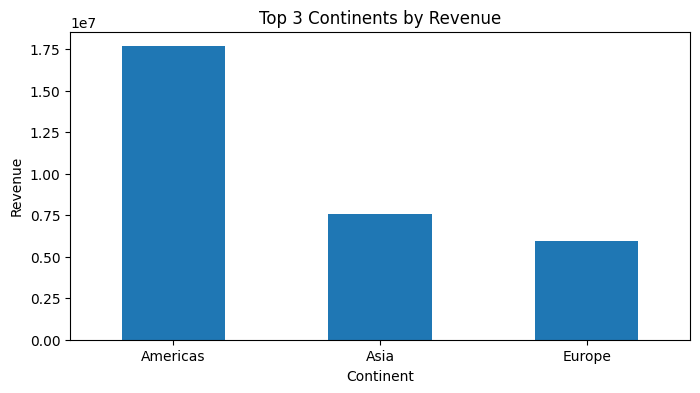

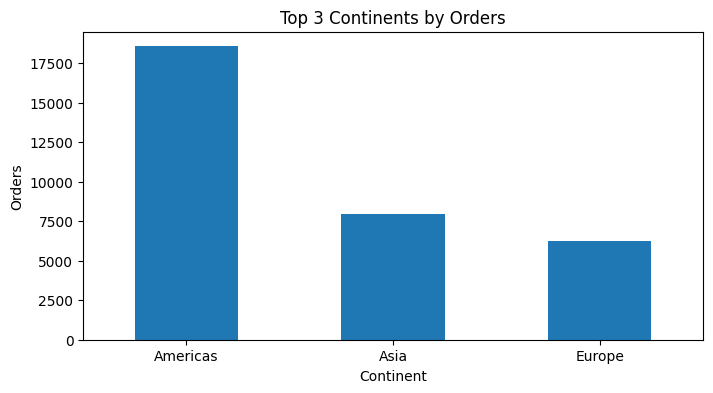

In [ ]:
# --- Revenue (Top 3 continents) ---
top3_continent_revenue = (
    df.groupby("continent")["revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(3)
)

plt.figure(figsize=(8, 4))
top3_continent_revenue.plot(kind="bar")
plt.title("Top 3 Continents by Revenue")
plt.xlabel("Continent")
plt.ylabel("Revenue")
plt.xticks(rotation=0)
plt.show()

# --- Orders (Top 3 continents) ---
top3_continent_orders = (
    orders_df.groupby("continent")["ga_session_id"]
      .count()
      .sort_values(ascending=False)
      .head(3)
)

plt.figure(figsize=(8, 4))
top3_continent_orders.plot(kind="bar")
plt.title("Top 3 Continents by Orders")
plt.xlabel("Continent")
plt.ylabel("Orders")
plt.xticks(rotation=0)
plt.show()

#### **Conclusion**

The Americas generate the highest total revenue and the largest number of completed orders.  
Asia ranks second, followed by Europe.

The ranking is consistent across both revenue and order volume, indicating stable demand patterns across regions.

### **4.2 Top Countries by Revenue and Orders**

In [ ]:
# Top countries by revenue
top_country_revenue = (
    df.groupby("country")["revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(5)
)

# Top countries by orders
top_country_orders = (
    orders_df.groupby("country")["ga_session_id"]
      .count()
      .sort_values(ascending=False)
)

# Combine into a single table
top_country_df = top_country_revenue.reset_index()
top_country_df.columns = ["country", "total_revenue"]

# Add orders
top_country_df["orders"] = (
    top_country_df["country"]
        .map(top_country_orders)
)

# AOV = revenue / orders
top_country_df["aov"] = (
    top_country_df["total_revenue"] / top_country_df["orders"]
).round(2)

top_country_df["revenue_share (%)"] = (
    top_country_df["total_revenue"] / df["revenue"].sum() * 100
).round(2)

display(
    top_country_df.style
        .hide(axis="index")
        .format({
            "total_revenue": "{:,.0f}",
            "orders": "{:,.0f}",
            "aov": "{:,.2f}",
            "revenue_share (%)": "{:.2f}%"
        })
)

country,total_revenue,orders,aov,revenue_share (%)
United States,"13,943,554","14,673",950.29,43.61%
India,"2,809,762","3,029",927.62,8.79%
Canada,"2,437,921","2,560",952.31,7.63%
United Kingdom,"938,318","1,029",911.87,2.93%
France,"710,693",678,"1,048.22",2.22%


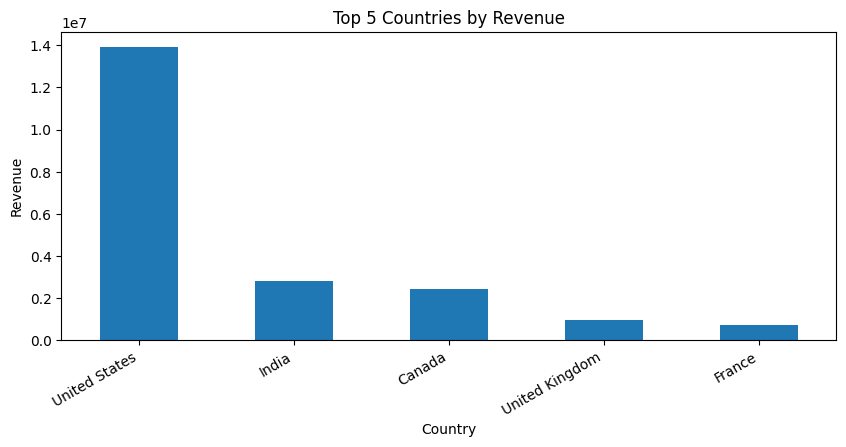

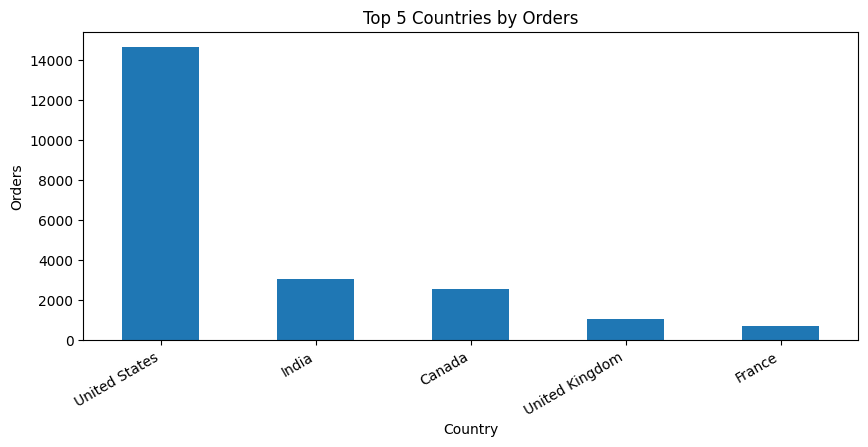

In [ ]:
# --- Revenue (Top 5 countries) ---
top5_country_revenue = (
    df.groupby("country")["revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(5)
)

plt.figure(figsize=(10, 4))
top5_country_revenue.plot(kind="bar")
plt.title("Top 5 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.xticks(rotation=30, ha="right")
plt.show()

# --- Orders (Top 5 countries) ---
top5_country_orders = (
    orders_df.groupby("country")["ga_session_id"]
      .count()
      .sort_values(ascending=False)
      .head(5)
)

plt.figure(figsize=(10, 4))
top5_country_orders.plot(kind="bar")
plt.title("Top 5 Countries by Orders")
plt.xlabel("Country")
plt.ylabel("Orders")
plt.xticks(rotation=30, ha="right")
plt.show()

#### **Conclusion**

The United States dominates both total revenue and order volume, significantly outperforming all other countries.

India and Canada follow, while the United Kingdom and France contribute substantially less.

The ranking is identical for both revenue and order count, suggesting consistent purchasing patterns and relatively proportional average order values across these markets.

#### **AOV Insight**

France has the highest average order value, indicating higher-priced purchases per transaction.

However, the United States dominates total revenue primarily due to significantly higher order volume rather than higher transaction size.

This suggests that revenue growth in the U.S. market is volume-driven, while France shows premium purchasing behavior but limited scale.

### **4.3 Top 10 Categories by Revenue**

In [ ]:
# Top 10 categories by total revenue
top_categories_global = (
    df.groupby("category")["revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

# Convert to clean DataFrame
top_categories_global_df = top_categories_global.reset_index()
top_categories_global_df.columns = ["category", "total_revenue"]

# Add revenue share
top_categories_global_df["revenue_share (%)"] = (
    top_categories_global_df["total_revenue"] / df["revenue"].sum() * 100
)

# Display formatted table
display(
    top_categories_global_df.style
        .hide(axis="index")
        .format({
            "total_revenue": "{:,.0f}",
            "revenue_share (%)": "{:.2f}%"
        })
)

# Top 3 concentration
top3_share = (
    top_categories_global_df.head(3)["total_revenue"].sum()
    / df["revenue"].sum()
) * 100

print(
    f"The top 3 product categories generate "
    f"{top3_share:.2f}% of total company revenue."
)

category,total_revenue,revenue_share (%)
Sofas & armchairs,"8,388,254",26.24%
Chairs,"6,147,749",19.23%
Beds,"4,919,725",15.39%
Bookcases & shelving units,"3,640,818",11.39%
Cabinets & cupboards,"2,336,500",7.31%
Outdoor furniture,"2,142,222",6.70%
Tables & desks,"1,790,308",5.60%
Chests of drawers & drawer units,"906,562",2.84%
Bar furniture,"735,503",2.30%
Children's furniture,"467,697",1.46%


The top 3 product categories generate 60.85% of total company revenue.


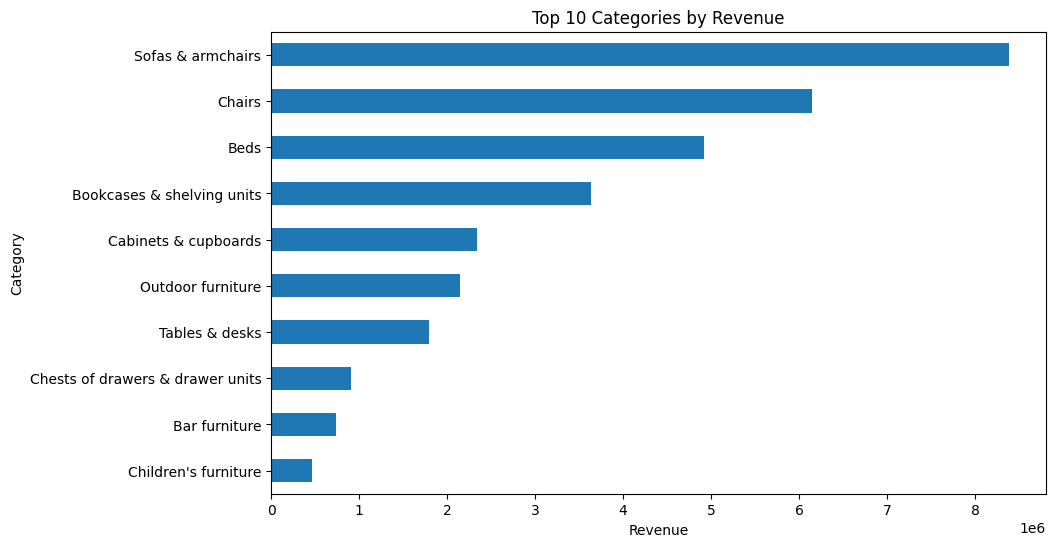

In [ ]:
top10_categories = (
    df.groupby("category")["revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .sort_values()  # for horizontal bar chart
)

plt.figure(figsize=(10, 6))
top10_categories.plot(kind="barh")
plt.title("Top 10 Categories by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Category")
plt.show()

#### **Conclusion**

The revenue structure is highly concentrated in large furniture categories.

Sofas & armchairs, Chairs, and Beds generate the majority of total revenue, indicating that the business is strongly dependent on high-ticket core household products.

Lower-ranked categories contribute significantly less, suggesting a long-tail distribution in product demand.

#### **Revenue Concentration Insight**

The top three product categories account for 60.85% of total company revenue.

This indicates a highly concentrated revenue structure, where the business strongly depends on a limited number of core furniture categories.

Such concentration increases operational and demand risk, as fluctuations in these categories may significantly impact total sales performance.

### **4.4 Top 10 Categories in the Top Revenue Country vs Global**

In [ ]:
# Country with highest revenue
top_country = top_country_revenue.index[0]
print(f"Top revenue country: {top_country}")

# Top 10 categories in that country
top_categories_top_country = (
    df[df["country"] == top_country]
      .groupby("category")["revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

# Convert to clean table
top_categories_country_df = top_categories_top_country.reset_index()
top_categories_country_df.columns = ["category", "total_revenue"]

# Add revenue share inside the country
country_total_revenue = df[df["country"] == top_country]["revenue"].sum()

top_categories_country_df["revenue_share_in_country (%)"] = (
    top_categories_country_df["total_revenue"] / country_total_revenue * 100
)

# Display formatted table
display(
    top_categories_country_df.style
        .hide(axis="index")
        .format({
            "total_revenue": "{:,.0f}",
            "revenue_share_in_country (%)": "{:.2f}%"
        })
)

# Revenue concentration inside the top country
country_top3_share = (
    top_categories_top_country.head(3).sum() / country_total_revenue
) * 100

# Global concentration
global_total_revenue = df["revenue"].sum()

global_top3_share = (
    top_categories_global.head(3).sum() / global_total_revenue
) * 100

print(
    f"Top 3 categories in {top_country} generate "
    f"{country_top3_share:.2f}% of the country's revenue."
)

print(
    f"Globally, the top 3 categories generate "
    f"{global_top3_share:.2f}% of total revenue."
)

Top revenue country: United States


category,total_revenue,revenue_share_in_country (%)
Sofas & armchairs,"3,707,144",26.59%
Chairs,"2,619,774",18.79%
Beds,"2,213,058",15.87%
Bookcases & shelving units,"1,567,607",11.24%
Cabinets & cupboards,"994,546",7.13%
Outdoor furniture,"929,245",6.66%
Tables & desks,"777,865",5.58%
Chests of drawers & drawer units,"382,388",2.74%
Bar furniture,"330,805",2.37%
Children's furniture,"207,575",1.49%


Top 3 categories in United States generate 61.25% of the country's revenue.
Globally, the top 3 categories generate 60.85% of total revenue.


,global_revenue,us_revenue
category,,
Sofas & armchairs,8388254.50,3707144.50
Chairs,6147748.80,2619773.80
Beds,4919725.00,2213058.00
Bookcases & shelving units,3640818.10,1567606.90
Cabinets & cupboards,2336499.50,994545.50
Outdoor furniture,2142222.20,929245.20
Tables & desks,1790307.50,777865.00
Chests of drawers & drawer units,906562.50,382388.00
Bar furniture,735503.00,330805.00


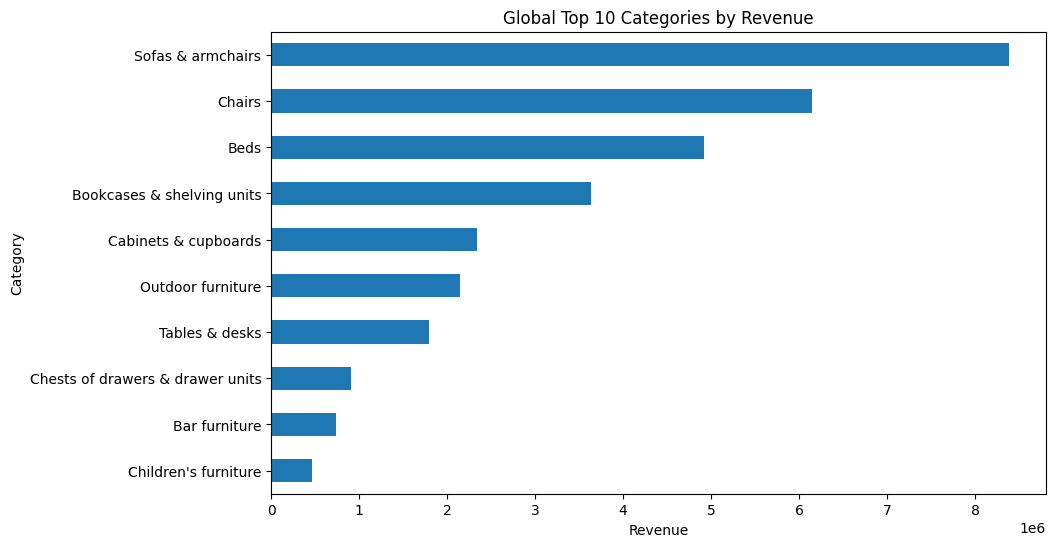

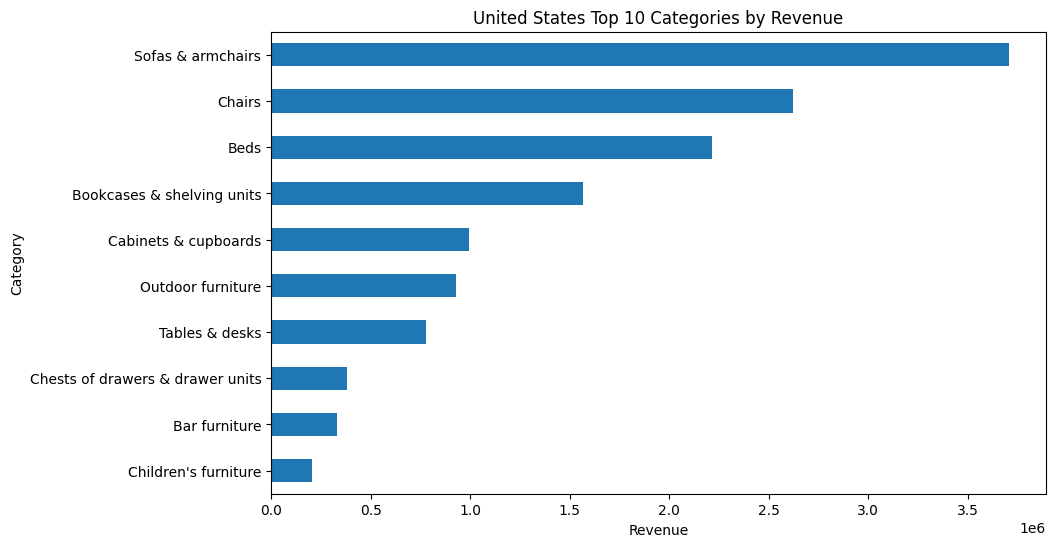

In [ ]:
# --- Global top 10 ---
global_top10 = (
    df.groupby("category")["revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

# --- US top 10 ---
us_top10 = (
    df[df["country"] == "United States"]
      .groupby("category")["revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

comparison = (
    pd.concat([global_top10, us_top10], axis=1)
      .rename(columns={"revenue": "global_revenue"})
)
comparison.columns = ["global_revenue", "us_revenue"]
display(comparison)

# --- Plot: Global ---
plt.figure(figsize=(10, 6))
global_top10.sort_values().plot(kind="barh")
plt.title("Global Top 10 Categories by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Category")
plt.show()

# --- Plot: United States ---
plt.figure(figsize=(10, 6))
us_top10.sort_values().plot(kind="barh")
plt.title("United States Top 10 Categories by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Category")
plt.show()

#### **Core Revenue Geographic Concentration**

The United States generates 43.89% of total revenue within the top three product categories.

Given that these categories account for 60.85% of overall company revenue, this indicates a dual concentration risk:

- Product concentration (limited number of core categories)
- Geographic concentration (heavy dependence on the U.S. market)

Such structure makes the business sensitive to demand fluctuations in its primary market.

### **4.5 Revenue Share by Device Type (%)**

In [ ]:
# Revenue by device
device_revenue = (
    df.groupby("device")["revenue"]
      .sum()
)

# Orders by device
device_orders = (
    orders_df.groupby("device")["ga_session_id"]
      .count()
)

# AOV by device
device_aov = (
    orders_df.groupby("device")["revenue"]
      .mean()
)

# Combine all metrics into one table
device_summary_df = device_revenue.reset_index()
device_summary_df.columns = ["device", "total_revenue"]

device_summary_df["orders"] = device_summary_df["device"].map(device_orders)
device_summary_df["average_order_value"] = (
    device_summary_df["device"].map(device_aov)
)

# Revenue share
device_summary_df["revenue_share (%)"] = (
    device_summary_df["total_revenue"] / df["revenue"].sum() * 100
)

# Sort by revenue
device_summary_df = device_summary_df.sort_values(
    "total_revenue",
    ascending=False
)

# Display formatted table
display(
    device_summary_df.style
        .hide(axis="index")
        .format({
            "total_revenue": "{:,.0f}",
            "orders": "{:,.0f}",
            "average_order_value": "{:,.2f}",
            "revenue_share (%)": "{:.2f}%"
        })
)

device,total_revenue,orders,average_order_value,revenue_share (%)
desktop,"18,864,039","19,702",957.47,59.00%
mobile,"12,384,226","13,113",944.42,38.73%
tablet,"723,466",723,"1,000.64",2.26%


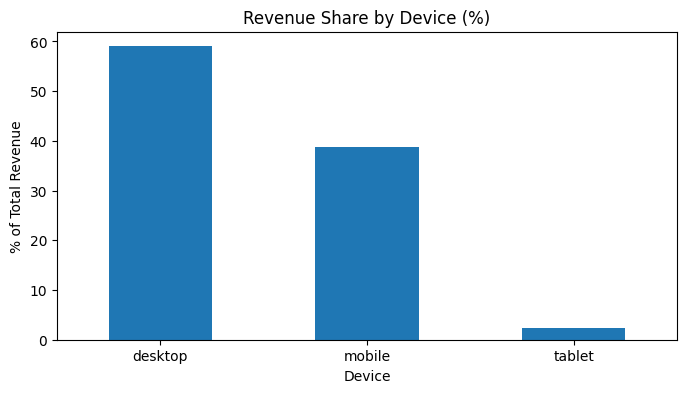

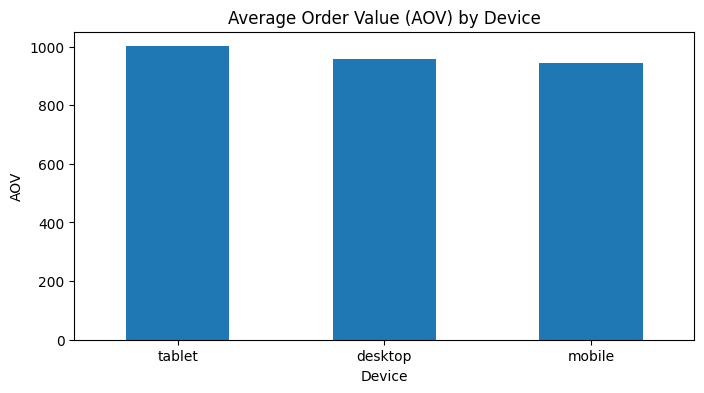

In [ ]:
# --- Revenue share by device ---
device_revenue = df.groupby("device")["revenue"].sum().sort_values(ascending=False)
device_share = (device_revenue / device_revenue.sum() * 100).round(2)

plt.figure(figsize=(8, 4))
device_share.plot(kind="bar")
plt.title("Revenue Share by Device (%)")
plt.xlabel("Device")
plt.ylabel("% of Total Revenue")
plt.xticks(rotation=0)
plt.show()

# --- AOV by device (purchases only) ---
aov_device = (
    orders_df.groupby("device")["revenue"]
      .mean()
      .sort_values(ascending=False)
      .round(2)
)

plt.figure(figsize=(8, 4))
aov_device.plot(kind="bar")
plt.title("Average Order Value (AOV) by Device")
plt.xlabel("Device")
plt.ylabel("AOV")
plt.xticks(rotation=0)
plt.show()

#### **Device-Level Revenue & AOV Insight**

Although tablet users show the highest average order value, the total revenue contribution from tablets remains minimal due to low purchase volume.

Desktop drives the majority of revenue by combining high order volume with strong average order value.

Mobile demonstrates comparable purchasing power to desktop, suggesting effective mobile optimization and cross-device purchasing behavior.

### **4.6 Revenue Share by Device Model (Top 10)**

In [ ]:
# Revenue share by device model (% of total revenue)

model_revenue = (
    df.groupby("mobile_model_name")["revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

# Convert to DataFrame
model_revenue_df = model_revenue.reset_index()
model_revenue_df.columns = ["mobile_model_name", "total_revenue"]

# Add revenue share
model_revenue_df["revenue_share (%)"] = (
    model_revenue_df["total_revenue"] / df["revenue"].sum() * 100
).round(2)

display(model_revenue_df)

,mobile_model_name,total_revenue,revenue_share (%)
0,Chrome,8899523.90,27.84
1,<Other>,6535330.80,20.44
2,Safari,6491062.10,20.30
3,iPhone,6420776.30,20.08
4,ChromeBook,1830458.70,5.73
5,Edge,697222.30,2.18
6,iPad,448854.20,1.40
7,Firefox,421066.90,1.32
8,Pixel 4 XL,118287.70,0.37
9,Pixel 3,109148.20,0.34


#### **Revenue Distribution by Device Models**

Revenue is concentrated across a limited number of device models and environments.

The highest revenue share is generated by Chrome-related environments, followed by Safari and iPhone users.

The presence of aggregated categories such as `Other` suggests partial limitations in device-level tracking granularity.

Overall, the revenue distribution indicates platform concentration rather than wide fragmentation across many device models.

### **4.7 Revenue Share by Traffic Source (%)**

In [ ]:
# Total company revenue (used for share calculation)
total_revenue = df["revenue"].sum()

# Aggregate revenue and orders by traffic source
traffic_summary = (
    df.groupby("traffic_source_info")
      .agg(
          total_revenue=("revenue", "sum"),
          orders=("ga_session_id", lambda x: x[df.loc[x.index, "revenue"].notna()].count())
      )
      .sort_values("total_revenue", ascending=False)
      .head(10)
      .reset_index()
)

# Calculate revenue share
traffic_summary["revenue_share (%)"] = (
    traffic_summary["total_revenue"] / total_revenue * 100
).round(2)

# Calculate AOV
traffic_summary["aov"] = (
    traffic_summary["total_revenue"] / traffic_summary["orders"]
).round(2)

# Reorder columns
traffic_summary = traffic_summary[
    ["traffic_source_info", "total_revenue", "orders", "revenue_share (%)", "aov"]
]

# Display formatted table
display(
    traffic_summary.style
        .hide(axis="index")
        .format({
            "total_revenue": "{:,.0f}",
            "revenue_share (%)": "{:.2f}%",
            "aov": "{:,.2f}"
        })
)

traffic_source_info,total_revenue,orders,revenue_share (%),aov
(organic) / organic,"10,935,240",11430,34.20%,956.71
(direct) / (none),"7,494,923",7800,23.44%,960.89
(referral) / referral,"5,641,855",6001,17.65%,940.15
/,"4,491,351",4803,14.05%,935.11
(data deleted) / (data deleted),"2,002,337",2055,6.26%,974.37
/ cpc,"1,366,440",1407,4.27%,971.17
/ (data deleted),"39,584",42,0.12%,942.48
(data deleted) /,0,0,0.00%,nan
/ referral,0,0,0.00%,nan


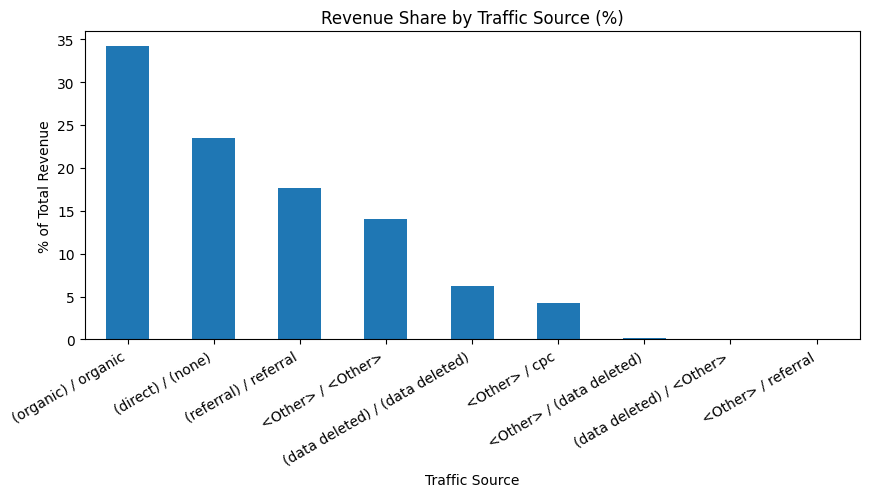

In [ ]:
source_revenue = df.groupby("traffic_source_info")["revenue"].sum().sort_values(ascending=False)
source_share = (source_revenue / source_revenue.sum() * 100).round(2)

plt.figure(figsize=(10, 4))
source_share.plot(kind="bar")
plt.title("Revenue Share by Traffic Source (%)")
plt.xlabel("Traffic Source")
plt.ylabel("% of Total Revenue")
plt.xticks(rotation=30, ha="right")
plt.show()

#### **Traffic Source Revenue Insight**

Revenue attribution at the source level confirms the dominance of organic and direct traffic.

However, a significant share of revenue is categorized as `Other` (18.45%), suggesting potential inconsistencies in traffic labeling or incomplete campaign tracking.

The presence of "(data deleted)" traffic (6.26%) indicates attribution loss due to privacy restrictions or tracking limitations.

Compared to traffic channels, source-level data appears more fragmented and less structured.

### **4.8 Revenue Share by Traffic Channel (%)**

In [ ]:
# Revenue by traffic channel
traffic_share = (
    df.groupby("traffic_channel")["revenue"]
      .sum()
      .sort_values(ascending=False)
)

# Convert to clean DataFrame
traffic_share_df = traffic_share.reset_index()
traffic_share_df.columns = ["traffic_channel", "total_revenue"]

# Add revenue share
traffic_share_df["revenue_share (%)"] = (
    traffic_share_df["total_revenue"] / df["revenue"].sum() * 100
)

# Display formatted table
display(
    traffic_share_df.style
        .hide(axis="index")
        .format({
            "total_revenue": "{:,.0f}",        # thousands separator
            "revenue_share (%)": "{:.2f}%"     # percent format
        })
)

traffic_channel,total_revenue,revenue_share (%)
Organic Search,"11,433,152",35.76%
Paid Search,"8,511,049",26.62%
Direct,"7,494,923",23.44%
Social Search,"2,532,106",7.92%
Undefined,"2,000,501",6.26%


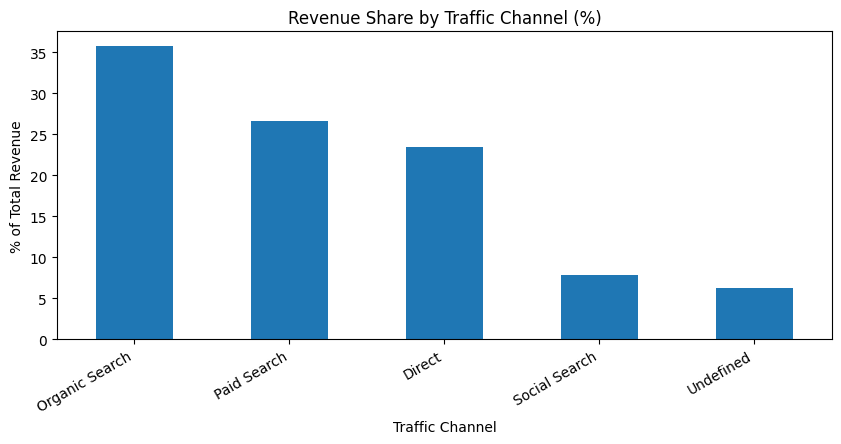

In [ ]:
channel_revenue = df.groupby("traffic_channel")["revenue"].sum().sort_values(ascending=False)
channel_share = (channel_revenue / channel_revenue.sum() * 100).round(2)

plt.figure(figsize=(10, 4))
channel_share.plot(kind="bar")
plt.title("Revenue Share by Traffic Channel (%)")
plt.xlabel("Traffic Channel")
plt.ylabel("% of Total Revenue")
plt.xticks(rotation=30, ha="right")
plt.show()

#### **Traffic Channel Revenue Insight**

Organic Search generates the highest revenue share (35.76%), followed by Paid Search (26.62%).

Together, search-based channels account for over 62% of total revenue, indicating strong dependence on search-driven traffic.

Direct traffic contributes 23.44%, suggesting brand strength and repeat purchasing behavior.

Social traffic plays a relatively minor role in revenue generation.

The presence of 6.26% Undefined traffic indicates partial attribution limitations.

### **4.9 Email Verification Rate (Registered Users)**

Email verified rate (%): 71.7


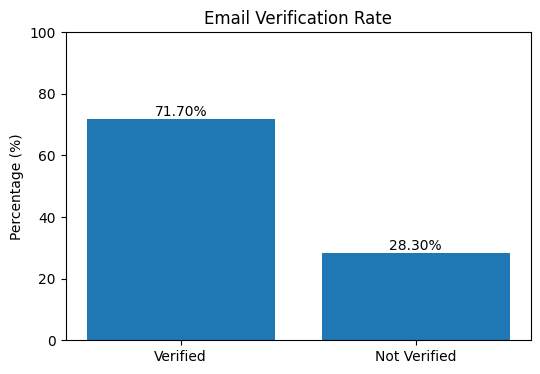

In [ ]:
registered = df[df["registered_user_id"].notna()].copy()

email_verified_rate = registered["is_email_verified"].mean() * 100
print("Email verified rate (%):", round(email_verified_rate, 2))

# Data for visualization
labels = ["Verified", "Not Verified"]
values = [email_verified_rate, 100 - email_verified_rate]

plt.figure(figsize=(6,4))
plt.bar(labels, values)

plt.title("Email Verification Rate")
plt.ylabel("Percentage (%)")

for i, v in enumerate(values):
    plt.text(i, v + 1, f"{v:.2f}%", ha="center")

plt.ylim(0, 100)

plt.show()

#### **Email Verification Insight**

71.7% of registered users have verified their email address.

This indicates a relatively high-quality subscriber base and suggests that email marketing campaigns can effectively reach the majority of registered users.

However, nearly 28% of accounts remain unverified, representing a potential opportunity for optimization in the onboarding and confirmation process.

### **4.10 Unsubscribe Rate (Registered Users)**

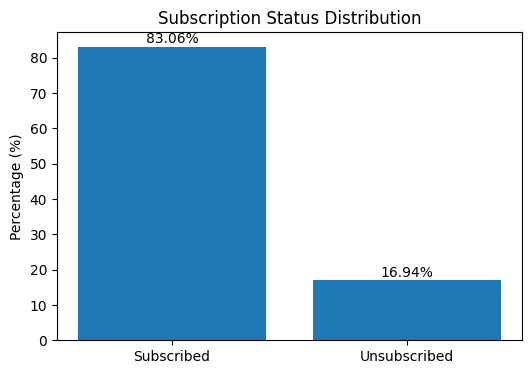

In [ ]:
# Calculate rates
unsubscribe_rate = (1 - registered["is_subscribed"].mean()) * 100
subscribe_rate = 100 - unsubscribe_rate

labels = ["Subscribed", "Unsubscribed"]
values = [subscribe_rate, unsubscribe_rate]

plt.figure(figsize=(6,4))

plt.bar(labels, values)

plt.title("Subscription Status Distribution")
plt.ylabel("Percentage (%)")

for i, v in enumerate(values):
    plt.text(i, v + 1, f"{v:.2f}%", ha="center")

plt.show()

#### **Unsubscribe Rate Insight**

16.94% of registered users have unsubscribed from email communications.

This indicates a moderate churn level within the subscriber base, while the majority (over 83%) remain engaged.

The unsubscribe rate appears manageable but highlights potential opportunities to improve content relevance and user segmentation strategies.

### **4.11 Revenue Comparison: Subscribed vs Unsubscribed Users**

In [ ]:
user_revenue = (
    registered.groupby(["registered_user_id", "is_subscribed"])["revenue"]
      .sum()
      .reset_index()
)

sub_revenue = user_revenue[user_revenue["is_subscribed"] == 1]["revenue"]
unsub_revenue = user_revenue[user_revenue["is_subscribed"] == 0]["revenue"]

print("Subscribed users:", sub_revenue.shape[0])
print("Unsubscribed users:", unsub_revenue.shape[0])

print("Avg revenue per user (subscribed):", round(sub_revenue.mean(), 2))
print("Avg revenue per user (unsubscribed):", round(unsub_revenue.mean(), 2))

t_stat, p_value = stats.ttest_ind(
    sub_revenue,
    unsub_revenue,
    equal_var=False  # Welch correction
)

print("t-statistic:", round(t_stat, 4))
print("p-value:", round(p_value, 6))

Subscribed users: 23210
Unsubscribed users: 4735
Avg revenue per user (subscribed): 92.67
Avg revenue per user (unsubscribed): 91.18
t-statistic: 0.1904
p-value: 0.849033


#### **Revenue Comparison: Subscribed vs Unsubscribed Users**

Subscribed users generate an average revenue of 92.67 per user, while unsubscribed users generate 91.18.

To assess whether this difference is statistically significant, a Welch’s t-test was conducted to compare the two independent groups.

The resulting p-value is greater than 0.05, indicating that the observed difference in average revenue is not statistically significant.

Therefore, there is no sufficient evidence to conclude that email subscription status has a meaningful impact on purchasing behavior.

This suggests that the current email strategy does not significantly influence revenue performance and may require further optimization to drive measurable business impact.

### **4.12 Top Countries by Number of Registered Users**

In [ ]:
top_registered_countries = (
    df[df["registered_user_id"].notna()]
      .groupby("country")["registered_user_id"]
      .nunique()
      .sort_values(ascending=False)
      .head(10)
)

# Convert to clean DataFrame format
top_registered_countries_df = top_registered_countries.reset_index()
top_registered_countries_df.columns = ["country", "registered_users_count"]

display(top_registered_countries_df)

,country,registered_users_count
0,United States,12384
1,India,2687
2,Canada,2067
3,United Kingdom,859
4,France,553
5,Spain,536
6,Taiwan,500
7,China,490
8,Germany,490
9,Italy,386


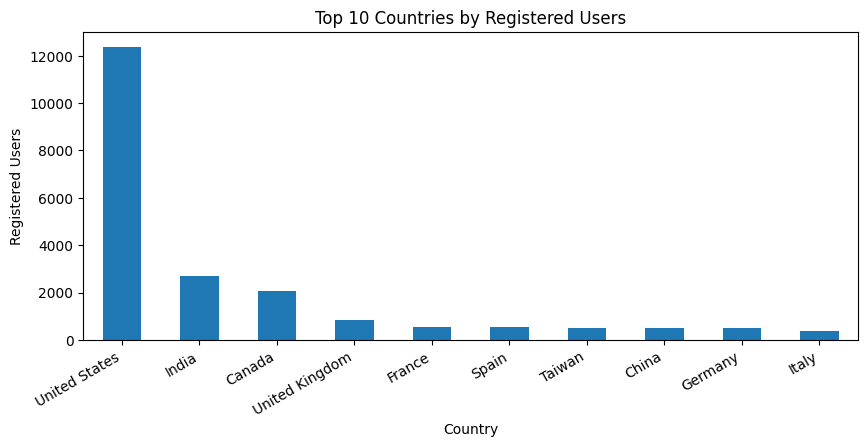

In [ ]:
top10_registered = (
    df[df["registered_user_id"].notna()]
      .groupby("country")["registered_user_id"]
      .nunique()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10, 4))
top10_registered.plot(kind="bar")
plt.title("Top 10 Countries by Registered Users")
plt.xlabel("Country")
plt.ylabel("Registered Users")
plt.xticks(rotation=30, ha="right")
plt.show()

#### **Registered User Distribution by Country**

The United States has the largest number of registered users, significantly exceeding all other countries.

India and Canada follow at a substantial distance, while European markets show a more distributed and fragmented subscriber base.

The distribution of registered users closely mirrors the revenue distribution across countries, indicating strong alignment between subscriber engagement and purchasing activity.

### **4.13 Purchase Session Rate by Continent**

In [ ]:
# Total sessions per continent
sessions_total = df.groupby("continent")["ga_session_id"].nunique()

# Sessions with purchase per continent
sessions_with_purchase = orders_df.groupby("continent")["ga_session_id"].nunique()

# Purchase session rate (%)
purchase_session_rate = (
    (sessions_with_purchase / sessions_total) * 100
).round(2).sort_values(ascending=False)

# Convert to clean DataFrame
purchase_session_rate_df = purchase_session_rate.reset_index()
purchase_session_rate_df.columns = ["continent", "purchase_session_rate (%)"]

display(purchase_session_rate_df)

,continent,purchase_session_rate (%)
0,Oceania,9.83
1,Europe,9.61
2,Americas,9.60
3,Asia,9.57
4,Africa,9.36
5,(not set),8.93


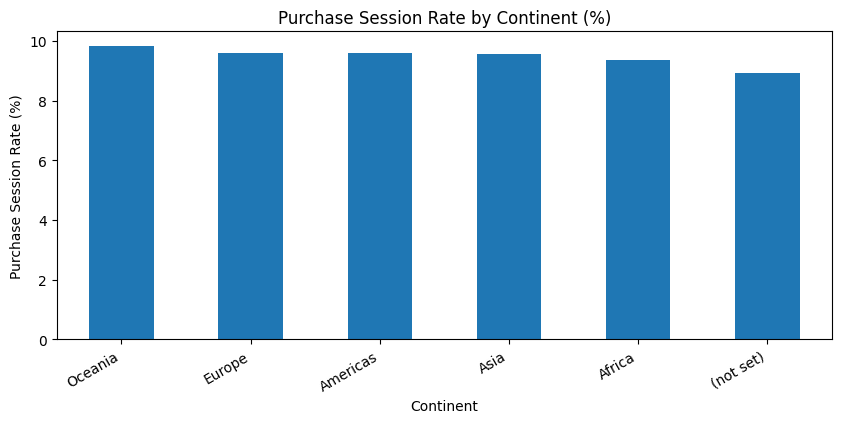

In [ ]:
sessions_total = df.groupby("continent")["ga_session_id"].nunique()
sessions_with_purchase = orders_df.groupby("continent")["ga_session_id"].nunique()

purchase_session_rate = ((sessions_with_purchase / sessions_total) * 100).round(2).sort_values(ascending=False)

plt.figure(figsize=(10, 4))
purchase_session_rate.plot(kind="bar")
plt.title("Purchase Session Rate by Continent (%)")
plt.xlabel("Continent")
plt.ylabel("Purchase Session Rate (%)")
plt.xticks(rotation=30, ha="right")
plt.show()

### **Insight: Purchase Session Rate by Continent**

The purchase session rate is relatively consistent across continents, ranging from 9.36% to 9.83%.

Oceania shows the highest conversion rate, while the Americas are not the leader in terms of conversion despite generating the highest total revenue.

This suggests that revenue differences between continents are primarily driven by traffic volume rather than conversion efficiency.

Overall, purchasing behavior appears stable across geographic regions.

### **4.14 Insight: Average Revenue per Purchased Session (AOV Proxy) by Country**

In [ ]:
# Top 10 countries by total revenue
top10_countries = (
    df.groupby("country")["revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .index
)

# Build summary table (purchases only)
country_summary = (
    orders_df[orders_df["country"].isin(top10_countries)]
      .groupby("country")
      .agg(
          total_revenue=("revenue", "sum"),
          orders=("ga_session_id", "count"),
          aov=("revenue", "mean")
      )
      .sort_values("total_revenue", ascending=False)
)

# Add revenue share within top-10 and overall
country_summary["revenue_share_top10_%"] = (
    country_summary["total_revenue"] / country_summary["total_revenue"].sum() * 100
).round(2)

country_summary["revenue_share_total_%"] = (
    country_summary["total_revenue"] / orders_df["revenue"].sum() * 100
).round(2)

# Round AOV for readability
country_summary["aov"] = country_summary["aov"].round(2)
country_summary["total_revenue"] = country_summary["total_revenue"].round(2)

display(country_summary.reset_index())

,country,total_revenue,orders,aov,revenue_share_top10_%,revenue_share_total_%
0,United States,13943553.90,14673,950.29,58.91,43.61
1,India,2809762.00,3029,927.62,11.87,8.79
2,Canada,2437921.00,2560,952.31,10.30,7.63
3,United Kingdom,938317.90,1029,911.87,3.96,2.93
4,France,710692.80,678,1048.22,3.00,2.22
5,Spain,631546.70,658,959.80,2.67,1.98
6,Germany,599221.40,642,933.37,2.53,1.87
7,China,588329.60,600,980.55,2.49,1.84
8,Taiwan,552710.30,564,979.98,2.34,1.73
9,Singapore,456447.20,454,1005.39,1.93,1.43


In [ ]:
# Top 10 countries by total revenue (overall, based on all sessions)
top10_countries = (
    df.groupby("country")["revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .index
)

# Sessions metrics (all sessions vs purchase sessions)
sessions_total_country = (
    df[df["country"].isin(top10_countries)]
      .groupby("country")["ga_session_id"]
      .nunique()
)

sessions_with_purchase_country = (
    orders_df[orders_df["country"].isin(top10_countries)]
      .groupby("country")["ga_session_id"]
      .nunique()
)

purchase_session_rate_country = (
    (sessions_with_purchase_country / sessions_total_country) * 100
)

# Purchases-only summary
country_summary = (
    orders_df[orders_df["country"].isin(top10_countries)]
      .groupby("country")
      .agg(
          total_revenue=("revenue", "sum"),
          orders=("ga_session_id", "count"),
          aov=("revenue", "mean")
      )
      .sort_values("total_revenue", ascending=False)
)

# Add revenue share within top-10 and overall (purchases only)
country_summary["revenue_share_top10 (%)"] = (
    country_summary["total_revenue"] / country_summary["total_revenue"].sum() * 100
)

country_summary["revenue_share_total (%)"] = (
    country_summary["total_revenue"] / orders_df["revenue"].sum() * 100
)

# Add sessions & purchase session rate
country_summary["sessions_total"] = country_summary.index.map(sessions_total_country)
country_summary["sessions_with_purchase"] = country_summary.index.map(sessions_with_purchase_country)
country_summary["purchase_session_rate (%)"] = country_summary.index.map(purchase_session_rate_country)

# Final clean table
country_summary_df = country_summary.reset_index()

display(
    country_summary_df.style
        .hide(axis="index")
        .format({
            "total_revenue": "{:,.0f}",
            "orders": "{:,.0f}",
            "aov": "{:,.2f}",
            "revenue_share_top10 (%)": "{:.2f}%",
            "revenue_share_total (%)": "{:.2f}%",
            "sessions_total": "{:,.0f}",
            "sessions_with_purchase": "{:,.0f}",
            "purchase_session_rate (%)": "{:.2f}%"
        })
)

country,total_revenue,orders,aov,revenue_share_top10 (%),revenue_share_total (%),sessions_total,sessions_with_purchase,purchase_session_rate (%)
United States,"13,943,554","14,673",950.29,58.91%,43.61%,"153,470","14,673",9.56%
India,"2,809,762","3,029",927.62,11.87%,8.79%,"32,763","3,029",9.25%
Canada,"2,437,921","2,560",952.31,10.30%,7.63%,"25,994","2,560",9.85%
United Kingdom,"938,318","1,029",911.87,3.96%,2.93%,"11,003","1,029",9.35%
France,"710,693",678,"1,048.22",3.00%,2.22%,"6,958",678,9.74%
Spain,"631,547",658,959.80,2.67%,1.98%,"6,505",658,10.12%
Germany,"599,221",642,933.37,2.53%,1.87%,"6,196",642,10.36%
China,"588,330",600,980.55,2.49%,1.84%,"6,066",600,9.89%
Taiwan,"552,710",564,979.98,2.34%,1.73%,"5,879",564,9.59%
Singapore,"456,447",454,"1,005.39",1.93%,1.43%,"4,594",454,9.88%


#### **Country-Level Revenue Structure Insight**

The United States accounts for 43.61% of total company revenue, making it the dominant market.

However, the U.S. does not have the highest average order value, indicating that revenue leadership is driven primarily by purchase volume rather than transaction size.

Countries such as France and Singapore demonstrate higher AOV but significantly lower order volume, suggesting premium-oriented but smaller-scale markets.

Overall, revenue is geographically concentrated, with the top three countries generating nearly 60% of total company revenue.

### **4.15 Insight: Revenue by Traffic Channel and Device (Pivot)**

In [ ]:
# Total revenue (for percentage calculations)
total_revenue = orders_df["revenue"].sum()

# Absolute revenue pivot
pivot_abs = pd.pivot_table(
    orders_df,
    values="revenue",
    index="traffic_channel",
    columns="device",
    aggfunc="sum"
).fillna(0)

# Share of total revenue (% of total company revenue)
pivot_total_share = (pivot_abs / total_revenue * 100).round(2)

# Share within channel (% distribution inside each traffic channel)
pivot_channel_share = (
    pivot_abs.div(pivot_abs.sum(axis=1), axis=0) * 100
).round(2)

# Combine into one clean multi-level table
pivot_final = pd.concat(
    {
        "Revenue": pivot_abs.round(2),
        "% of Total Revenue": pivot_total_share,
        "% Within Channel": pivot_channel_share
    },
    axis=1
)

display(
    pivot_final.style
        .format("{:,.0f}")
)

#### **Traffic Channel × Device Revenue Insight**

Revenue distribution across device types is remarkably consistent across all traffic channels.

Desktop accounts for approximately 58–60% of revenue within every channel, while mobile contributes around 38–40%, and tablet remains marginal.

This indicates stable cross-device purchasing behavior regardless of acquisition source.

Revenue differences between traffic channels are primarily driven by traffic volume rather than device composition.

### **4.16 Traffic Channel × Device “Heatmap” (Share of Total Revenue)**

This view highlights which combinations of traffic channel and device contribute the most to total revenue.
Values are shown as **% of total company revenue**.

In [ ]:
# Pivot: revenue by traffic channel and device
pivot_abs = pd.pivot_table(
    orders_df,
    values="revenue",
    index="traffic_channel",
    columns="device",
    aggfunc="sum",
    fill_value=0
)

# Convert to percentage of total revenue
pivot_percent = (pivot_abs / pivot_abs.values.sum() * 100).round(2)

display(pivot_percent)

device,desktop,mobile,tablet
traffic_channel,,,
Direct,13.99,8.99,0.46
Organic Search,21.25,13.79,0.72
Paid Search,15.57,10.42,0.64
Social Search,4.53,3.15,0.24
Undefined,3.67,2.39,0.20


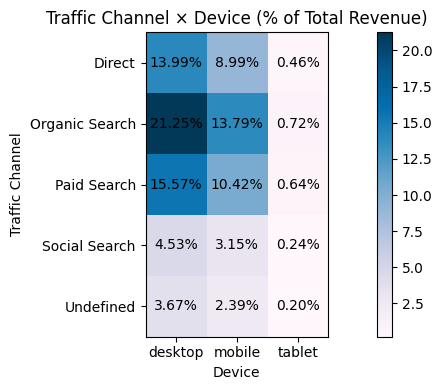

In [ ]:
# Prepare data
rows = pivot_percent.index
cols = pivot_percent.columns
data = pivot_percent.values

fig, ax = plt.subplots(figsize=(10,4))

im = ax.imshow(data, cmap="PuBu")

# Axis labels
ax.set_xticks(range(len(cols)))
ax.set_yticks(range(len(rows)))
ax.set_xticklabels(cols)
ax.set_yticklabels(rows)

ax.set_title("Traffic Channel × Device (% of Total Revenue)")
ax.set_xlabel("Device")
ax.set_ylabel("Traffic Channel")

# Add values inside cells
for i in range(len(rows)):
    for j in range(len(cols)):
        ax.text(j, i, f"{data[i, j]:.2f}%", ha="center", va="center")

plt.colorbar(im)
plt.tight_layout()
plt.show()

## **5. Sales Dynamics**


This section analyzes revenue trends over time, seasonality patterns, and performance differences across continents, traffic channels, and device types.

### **5.1 Total Revenue by Date**

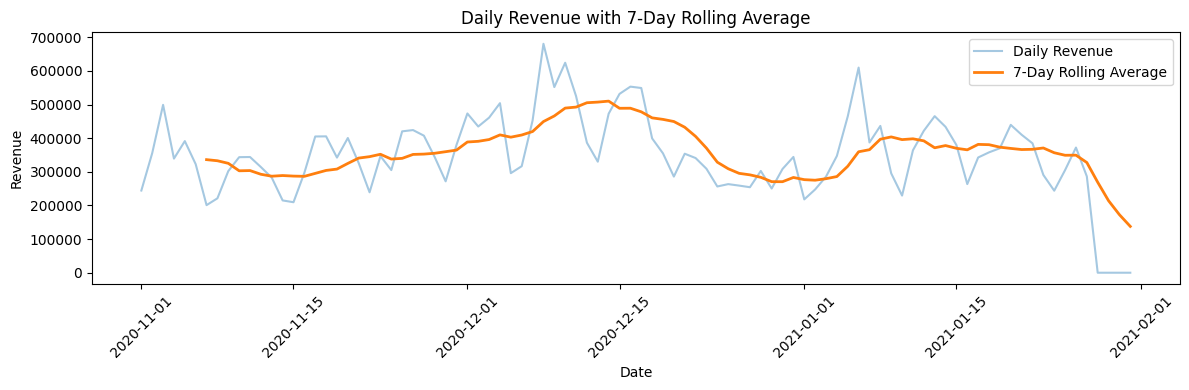

In [ ]:
# --- Daily total revenue ---
daily_revenue = (
    df.groupby("order_date")["revenue"]
      .sum()
      .sort_index()
)

# --- 7-day rolling average ---
rolling_revenue = daily_revenue.rolling(window=7).mean()

plt.figure(figsize=(12, 4))
plt.plot(daily_revenue.index, daily_revenue.values, alpha=0.4, label="Daily Revenue")
plt.plot(rolling_revenue.index, rolling_revenue.values, linewidth=2, label="7-Day Rolling Average")

plt.title("Daily Revenue with 7-Day Rolling Average")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### **Daily Revenue Trend Insight**

Revenue exhibits clear short-term fluctuations with noticeable peaks in early December and early January.

The 7-day rolling average confirms the presence of cyclical patterns, potentially reflecting weekly seasonality and holiday-driven demand.

The sharp decline at the end of the period likely reflects incomplete data rather than an actual business downturn.

### **5.2 Weekly Seasonality**

This subsection examines whether revenue patterns vary systematically across weekdays.

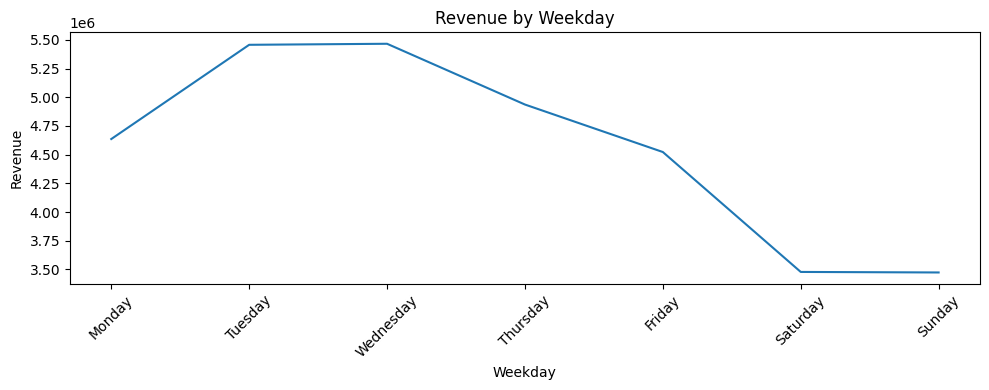

In [ ]:
# Add weekday column
df["weekday"] = df["order_date"].dt.day_name()

# Aggregate revenue by weekday
weekday_revenue = (
    df.groupby("weekday")["revenue"]
      .sum()
)

# Ensure correct weekday order
week_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
weekday_revenue = weekday_revenue.reindex(week_order)

plt.figure(figsize=(10, 4))
plt.plot(weekday_revenue.index, weekday_revenue.values)
plt.title("Revenue by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### **Weekly Seasonality Insight**

Revenue peaks on Tuesday and Wednesday, indicating stronger purchasing activity during midweek.

A consistent decline is observed toward the weekend, with Saturday and Sunday generating the lowest revenue.

This pattern suggests that customer purchasing behavior is more active during business days rather than weekends, potentially reflecting workday browsing and planned purchases rather than impulse buying.

The observed weekly structure indicates clear and stable weekday seasonality.

### **5.3 Revenue Trend by Continent**

This subsection analyzes revenue dynamics across the top three continents: Americas, Asia, and Europe.
Different continents are displayed using separate lines for comparison.

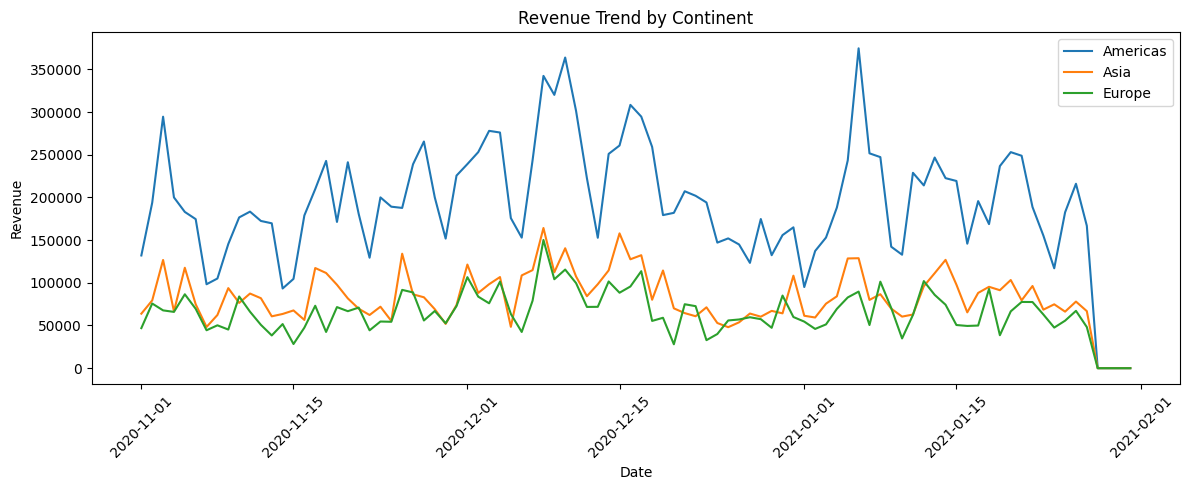

In [ ]:
# Select top 3 continents
top3_continents = ["Americas", "Asia", "Europe"]

continent_trend = (
    df[df["continent"].isin(top3_continents)]
      .groupby(["order_date", "continent"])["revenue"]
      .sum()
      .unstack()
      .sort_index()
)

plt.figure(figsize=(12, 5))

for continent in continent_trend.columns:
    plt.plot(
        continent_trend.index,
        continent_trend[continent],
        label=continent
    )

plt.title("Revenue Trend by Continent")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### **Revenue Trend by Continent Insight**

The Americas consistently generate significantly higher revenue than Asia and Europe throughout the entire period.

Revenue fluctuations across all three continents appear highly synchronized, indicating the presence of global seasonal drivers rather than region-specific effects.

The similar trend structure across continents suggests that demand patterns are globally aligned, while revenue differences are primarily driven by market size rather than behavioral variation.

### **5.4 Revenue Trend by Traffic Channel**

This subsection analyzes revenue dynamics across different traffic channels.
Each traffic channel is displayed as a separate line for comparison.

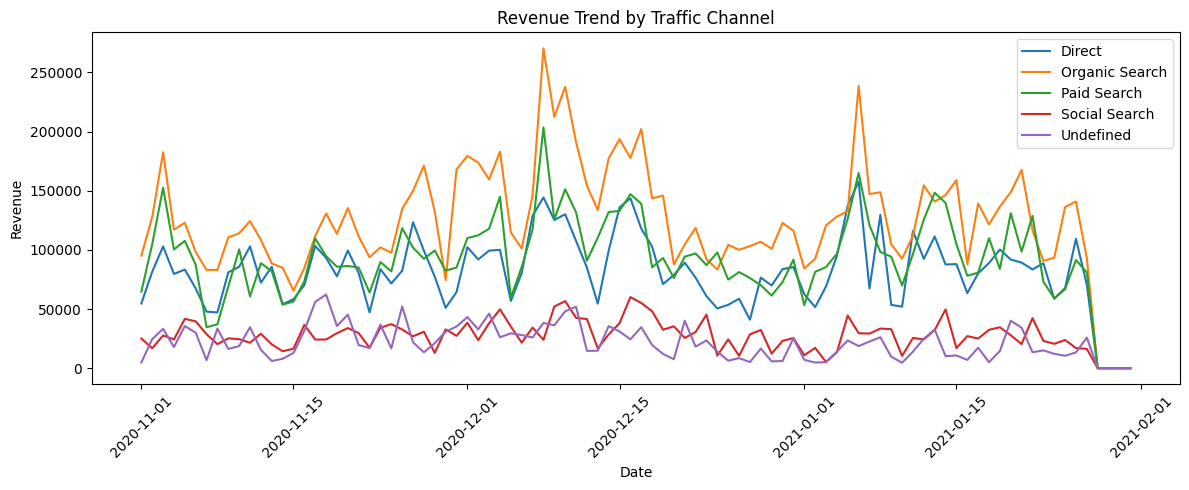

In [ ]:
# Aggregate daily revenue by traffic channel
channel_trend = (
    df.groupby(["order_date", "traffic_channel"])["revenue"]
      .sum()
      .unstack()
      .sort_index()
)

plt.figure(figsize=(12, 5))

for channel in channel_trend.columns:
    plt.plot(
        channel_trend.index,
        channel_trend[channel],
        label=channel
    )

plt.title("Revenue Trend by Traffic Channel")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### **Revenue Trend by Traffic Channel Insight**

Organic Search consistently generates the highest revenue throughout the period, making it the primary traffic driver.

Paid Search follows closely and demonstrates higher volatility, suggesting campaign-driven spikes.

Direct traffic shows stable performance, indicating consistent brand engagement.

Revenue peaks across channels occur simultaneously, implying that seasonal demand influences all traffic sources rather than individual channel effects.

### **5.5 Revenue Trend by Device**

This subsection analyzes revenue dynamics across different device types (desktop, mobile, tablet).
Each device type is displayed as a separate line for comparison.

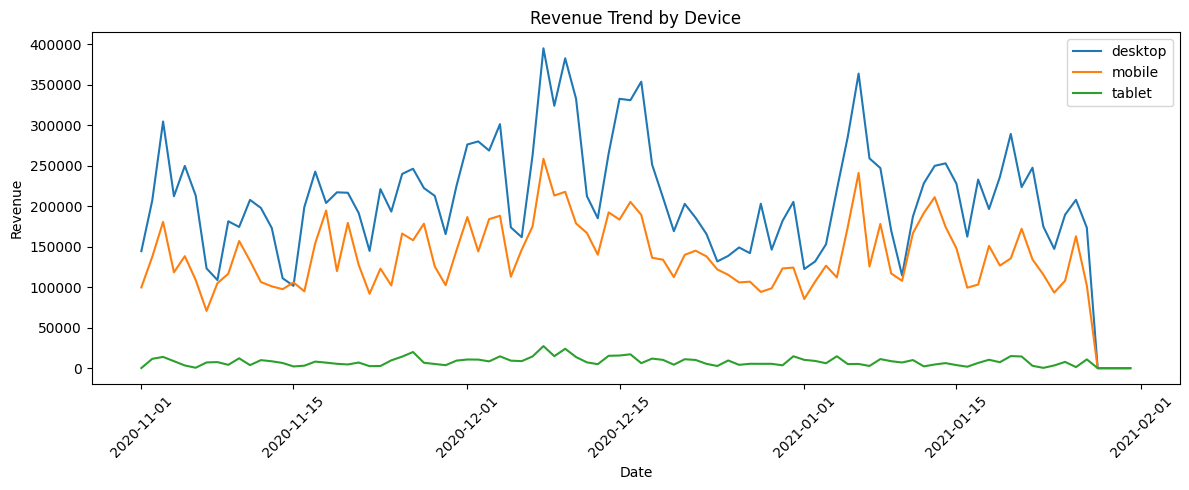

In [ ]:
# Aggregate daily revenue by device
device_trend = (
    df.groupby(["order_date", "device"])["revenue"]
      .sum()
      .unstack()
      .sort_index()
)

plt.figure(figsize=(12, 5))

for device in device_trend.columns:
    plt.plot(
        device_trend.index,
        device_trend[device],
        label=device
    )

plt.title("Revenue Trend by Device")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### **Revenue Trend by Device Insight**

Desktop consistently generates the highest revenue throughout the entire period, clearly dominating other device types.

Mobile contributes a substantial but consistently lower share, moving in close synchronization with desktop trends.

Tablet revenue remains marginal and does not significantly impact overall performance.

The synchronized peaks across all device types indicate that seasonal demand affects all platforms similarly, while revenue differences are primarily driven by usage volume rather than behavioral variation.

## **6. Pivot Tables**

In this section, we use pivot tables to explore multidimensional relationships between traffic sources, devices, countries, and product categories.

Pivot tables allow us to analyze data structure more deeply and identify hidden patterns across different business dimensions.

### **6.1 Sessions by Traffic Channel × Device**

This pivot table shows the number of unique sessions by traffic channel and device type.
Unknown values are excluded from the analysis.

In [ ]:
# 1) Clean unknown-like values (both NaN and placeholder strings)
unknown_values = {"Unknown", "Undefined", "(not set)", "not set", "None", ""}

pivot_sessions = df[
    df["traffic_channel"].notna()
    & df["device"].notna()
    & ~df["traffic_channel"].isin(unknown_values)
    & ~df["device"].isin(unknown_values)
].copy()

# 2) Pivot table: unique sessions by channel x device
pivot_sessions_table = pd.pivot_table(
    pivot_sessions,
    values="ga_session_id",
    index="traffic_channel",
    columns="device",
    aggfunc=pd.Series.nunique,
    fill_value=0
)

# 3) Add totals
pivot_sessions_table["Total"] = pivot_sessions_table.sum(axis=1)
pivot_sessions_table.loc["Total"] = pivot_sessions_table.sum(axis=0)

# 4) Sort rows by Total (excluding the final Total row)
pivot_sessions_table = pd.concat(
    [
        pivot_sessions_table.drop(index="Total").sort_values("Total", ascending=False),
        pivot_sessions_table.loc[["Total"]]
    ]
)

display(pivot_sessions_table.style
        .format("{:,.0f}")
)

# Calculate percentage distribution of device types within each traffic channel
# (row-wise share of sessions)

pivot_share_table = (
    pivot_sessions_table
        .drop(index="Total")            # Remove the total row
        .drop(columns="Total")          # Remove the total column
        .div(
            pivot_sessions_table
                .drop(index="Total")["Total"],  # Divide by total sessions per channel
            axis=0
        ) * 100                         # Convert to percentage
).round(2)

display(pivot_share_table.style
        .format("{:,.2f}")
)

device,desktop,mobile,tablet,Total
traffic_channel,,,,
Organic Search,"72,622","49,014","2,789","124,425"
Paid Search,"55,167","37,034","2,140","94,341"
Direct,"47,825","31,745","1,812","81,382"
Social Search,"16,288","10,988",638,"27,914"
Total,"191,902","128,781","7,379","328,062"


device,desktop,mobile,tablet
traffic_channel,,,
Organic Search,58.37,39.39,2.24
Paid Search,58.48,39.26,2.27
Direct,58.77,39.01,2.23
Social Search,58.35,39.36,2.29


#### **Insight**

Organic Search generates the highest number of sessions across all device types (124,425 total sessions), followed by Paid Search and Direct traffic.

Desktop dominates within every traffic channel, accounting for approximately 58% of sessions.
Mobile consistently contributes around 39%, while tablet remains marginal at ~2%.

The device distribution is remarkably stable across all traffic channels, indicating that user behavior patterns are structurally consistent regardless of acquisition source.

In [ ]:
# Base pivot (unique sessions)
pivot_sessions = pd.pivot_table(
    df[
        (df["traffic_channel"].notna()) &
        (df["device"].notna())
    ],
    values="ga_session_id",
    index="traffic_channel",
    columns="device",
    aggfunc="nunique",
    fill_value=0
)

# Add total
pivot_sessions["Total"] = pivot_sessions.sum(axis=1)

# Calculate % within channel
pivot_percent = (
    pivot_sessions.div(pivot_sessions["Total"], axis=0) * 100
).round(2)

# Format counts
pivot_sessions_fmt = pivot_sessions.map(lambda x: f"{x:,}")

# Combine count + %
combined_table = pivot_sessions_fmt.astype(str) + " (" + pivot_percent.astype(str) + "%)"

display(
    combined_table.style
        .set_caption("Sessions by Traffic Channel × Device (Count and % Within Channel)")
        .set_properties(**{"text-align": "center"})
)

device,desktop,mobile,tablet,Total
traffic_channel,,,,
Direct,"47,825 (58.77%)","31,745 (39.01%)","1,812 (2.23%)","81,382 (100.0%)"
Organic Search,"72,622 (58.37%)","49,014 (39.39%)","2,789 (2.24%)","124,425 (100.0%)"
Paid Search,"55,167 (58.48%)","37,034 (39.26%)","2,140 (2.27%)","94,341 (100.0%)"
Social Search,"16,288 (58.35%)","10,988 (39.36%)",638 (2.29%),"27,914 (100.0%)"
Undefined,"12,527 (58.31%)","8,486 (39.5%)",470 (2.19%),"21,483 (100.0%)"


In [ ]:
# Apply heatmap-style conditional formatting to highlight percentage intensity
# Darker colors indicate higher percentage values within the pivot table

pivot_percent[["desktop", "mobile", "tablet"]].style.background_gradient(
    cmap="YlGnBu"
).format("{:.2f}%")

device,desktop,mobile,tablet
traffic_channel,,,
Direct,58.77%,39.01%,2.23%
Organic Search,58.37%,39.39%,2.24%
Paid Search,58.48%,39.26%,2.27%
Social Search,58.35%,39.36%,2.29%
Undefined,58.31%,39.50%,2.19%


#### **Structural Device Distribution Across Channels**

The distribution of devices remains remarkably stable across all traffic channels.

Desktop consistently accounts for approximately 58% of sessions,
mobile contributes around 39%, and tablet remains below 3%.

This indicates that user device behavior is structurally consistent and not significantly influenced by acquisition channel.

### **6.2 Top-10 Categories by Revenue across Top-5 Countries**

This pivot table shows total revenue for the top-10 product categories
within the top-5 revenue-generating countries.

In [ ]:
# Top 5 countries by revenue
top5_countries = (
    df.groupby("country")["revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(5)
      .index
)

# Top 10 categories by revenue
top10_categories = (
    df.groupby("category")["revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .index
)

# Filter dataset
filtered_df = df[
    df["country"].isin(top5_countries) &
    df["category"].isin(top10_categories)
]

# Create pivot
pivot_revenue = pd.pivot_table(
    filtered_df,
    values="revenue",
    index="category",
    columns="country",
    aggfunc="sum",
    fill_value=0
)

# Add total column
pivot_revenue["Total"] = pivot_revenue.sum(axis=1)

# Sort by total revenue
pivot_revenue = pivot_revenue.sort_values("Total", ascending=False)

display(
    pivot_revenue.style
        .format("{:,.0f}")
        .set_caption("Total Revenue by Category and Country")
)

country,Canada,France,India,United Kingdom,United States,Total
category,,,,,,
Sofas & armchairs,"692,428","187,735","788,430","234,812","3,707,144","5,610,549"
Chairs,"417,741","134,029","544,309","188,519","2,619,774","3,904,373"
Beds,"354,772","116,414","358,320","133,816","2,213,058","3,176,380"
Bookcases & shelving units,"278,982","73,830","364,507","113,988","1,567,607","2,398,914"
Cabinets & cupboards,"181,802","59,102","191,888","71,684","994,546","1,499,022"
Outdoor furniture,"185,323","40,486","162,289","57,002","929,245","1,374,346"
Tables & desks,"132,678","42,299","186,158","49,374","777,865","1,188,374"
Chests of drawers & drawer units,"71,952","21,544","73,111","36,784","382,388","585,780"
Bar furniture,"51,724","11,199","57,657","22,103","330,805","473,488"


#### **Revenue Distribution by Category and Country**

The United States dominates revenue across nearly all product categories, significantly outperforming other markets.

Core product categories such as **Sofas & armchairs, Chairs, and Beds** generate the highest revenue across all top countries.

The revenue structure remains highly consistent across markets, suggesting similar customer preferences internationally.

High-value furniture categories drive the majority of global revenue.

### **6.3 Revenue by Traffic Channel × Continent**

In [ ]:
# Create pivot table: Revenue by Traffic Channel × Continent
pivot_channel_continent = pd.pivot_table(
    df,
    values="revenue",
    index="traffic_channel",
    columns="continent",
    aggfunc="sum",
    fill_value=0
)

# Remove '(not set)' column if it exists
pivot_channel_continent = pivot_channel_continent.drop(columns="(not set)", errors="ignore")

# Add Total column
pivot_channel_continent["Total"] = pivot_channel_continent.sum(axis=1)

# Sort by Total revenue
pivot_channel_continent = pivot_channel_continent.sort_values("Total", ascending=False)

# Reset index to convert it to a normal table
pivot_reset = pivot_channel_continent.reset_index()

# Select numeric columns for formatting
num_cols = pivot_reset.select_dtypes(include="number").columns

# Display styled table
display(
    pivot_reset.style
        .hide(axis="index")
        .format("{:,.0f}", subset=num_cols)
        .set_caption("Revenue by Traffic Channel and Continent")
        .set_properties(**{"text-align": "center"})
)

pivot_channel_continent.drop(columns="Total").style.background_gradient(
    cmap="YlGnBu"
).format("{:,.0f}")

traffic_channel,Africa,Americas,Asia,Europe,Oceania,Total
Organic Search,"129,908","6,294,563","2,725,954","2,154,139","113,508","11,418,072"
Paid Search,"88,195","4,627,454","2,039,256","1,620,206","116,006","8,491,118"
Direct,"70,028","4,222,962","1,755,294","1,343,094","82,102","7,473,480"
Social Search,"31,188","1,384,428","576,032","498,507","30,727","2,520,881"
Undefined,"11,912","1,135,873","504,762","318,678","22,887","1,994,112"


continent,Africa,Americas,Asia,Europe,Oceania
traffic_channel,,,,,
Organic Search,"129,908","6,294,563","2,725,954","2,154,139","113,508"
Paid Search,"88,195","4,627,454","2,039,256","1,620,206","116,006"
Direct,"70,028","4,222,962","1,755,294","1,343,094","82,102"
Social Search,"31,188","1,384,428","576,032","498,507","30,727"
Undefined,"11,912","1,135,873","504,762","318,678","22,887"


#### **Revenue Distribution by Traffic Channel and Continent**

Organic Search generates the highest revenue across all continents, making it the most important acquisition channel globally.

The Americas dominate revenue generation for every traffic channel, reflecting the larger market size and stronger purchasing activity in this region.

Paid Search and Direct traffic also contribute substantial revenue across continents, while Social Search and Undefined channels play a smaller role.

The similar structure across continents suggests that traffic channel performance is relatively consistent globally rather than region-specific.

### **6.4 Average Revenue per Order by Device × Traffic Channel**

In [ ]:
# Pivot table: Average revenue (AOV proxy) by Traffic Channel × Device
pivot_aov = pd.pivot_table(
    df,
    values="revenue",
    index="traffic_channel",
    columns="device",
    aggfunc="mean",
    fill_value=0
)

# Display numeric table
display(pivot_aov.round(2))

device,desktop,mobile,tablet
traffic_channel,,,
Direct,960.82,963.26,918.73
Organic Search,969.06,947.13,902.62
Paid Search,946.01,931.74,985.70
Social Search,908.02,945.27,1368.66
Undefined,993.19,915.22,1460.20


### **Heatmap Visualization**

In [ ]:
# Heatmap styling for better visual comparison
display(
    pivot_aov.style
        .background_gradient(cmap="YlGnBu")
        .format("{:,.0f}")
        .set_caption("Average Revenue per Order by Traffic Channel and Device")
)

device,desktop,mobile,tablet
traffic_channel,,,
Direct,961,963,919
Organic Search,969,947,903
Paid Search,946,932,986
Social Search,908,945,"1,369"
Undefined,993,915,"1,460"


### **6.5 Revenue by Category × Device (Top Categories)**

This pivot table shows how revenue is distributed across top product categories and device types.
It helps identify whether certain categories are more strongly associated with desktop or mobile purchases.

In [ ]:
# --- Select top categories by total revenue ---
top_categories = (
    df.groupby("category")["revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .index
)

df_cat_device = df[
    df["category"].isin(top_categories) &
    df["device"].notna()
]

# --- Pivot: total revenue by category × device ---
pivot_cat_device = pd.pivot_table(
    df_cat_device,
    values="revenue",
    index="category",
    columns="device",
    aggfunc="sum",
    fill_value=0
)

# Add Total and sort
pivot_cat_device["Total"] = pivot_cat_device.sum(axis=1)
pivot_cat_device = pivot_cat_device.sort_values("Total", ascending=False)

# Display numeric table
display(
    pivot_cat_device.style
        .format("{:,.0f}")
        .set_caption("Revenue by Category and Device")
)

device,desktop,mobile,tablet,Total
category,,,,
Sofas & armchairs,"4,888,456","3,310,256","189,542","8,388,254"
Chairs,"3,734,573","2,250,582","162,593","6,147,749"
Beds,"2,865,738","1,958,846","95,140","4,919,725"
Bookcases & shelving units,"2,129,667","1,437,188","73,963","3,640,818"
Cabinets & cupboards,"1,381,298","893,916","61,285","2,336,500"
Outdoor furniture,"1,248,421","846,724","47,078","2,142,222"
Tables & desks,"1,067,212","682,856","40,239","1,790,308"
Chests of drawers & drawer units,"537,674","350,846","18,043","906,562"
Bar furniture,"432,064","288,279","15,160","735,503"


#### **Heatmap View**

In [ ]:
display(
    pivot_cat_device.drop(columns="Total").style
        .background_gradient(cmap="YlGnBu")
        .format("{:,.0f}")
        .set_caption("Total Revenue by Category and Device (Top 10 Categories)")
)

device,desktop,mobile,tablet
category,,,
Sofas & armchairs,"4,888,456","3,310,256","189,542"
Chairs,"3,734,573","2,250,582","162,593"
Beds,"2,865,738","1,958,846","95,140"
Bookcases & shelving units,"2,129,667","1,437,188","73,963"
Cabinets & cupboards,"1,381,298","893,916","61,285"
Outdoor furniture,"1,248,421","846,724","47,078"
Tables & desks,"1,067,212","682,856","40,239"
Chests of drawers & drawer units,"537,674","350,846","18,043"
Bar furniture,"432,064","288,279","15,160"


#### **Insight**
Revenue across top product categories is dominated by desktop purchases, with desktop consistently generating the highest revenue in every category.

Mobile devices contribute a substantial share of revenue, typically accounting for around two-thirds of desktop revenue across most categories.

Tablet purchases represent only a small fraction of total revenue and do not significantly influence the overall sales structure.

Among the categories, **Sofas & armchairs**, **Chairs**, and **Beds** generate the highest revenue across all device types, indicating strong and consistent demand for core furniture products regardless of device used for purchase.

### **6.6 Revenue Share by Category and Device**

To better understand the structure of sales across devices, we analyze the share of revenue generated by desktop, mobile, and tablet devices within each product category.

This allows us to identify whether certain categories are more strongly associated with specific device types.

In [ ]:
# Remove Total before calculating percentage
pivot_no_total = pivot_cat_device.drop(columns="Total")

# Calculate revenue share
pivot_share = pivot_no_total.div(pivot_no_total.sum(axis=1), axis=0) * 100

display(
    pivot_share.style
        .background_gradient(cmap="YlGnBu")
        .format("{:.1f}%")
        .set_caption("Revenue Share by Category and Device (%)")
)

device,desktop,mobile,tablet
category,,,
Sofas & armchairs,58.3%,39.5%,2.3%
Chairs,60.7%,36.6%,2.6%
Beds,58.2%,39.8%,1.9%
Bookcases & shelving units,58.5%,39.5%,2.0%
Cabinets & cupboards,59.1%,38.3%,2.6%
Outdoor furniture,58.3%,39.5%,2.2%
Tables & desks,59.6%,38.1%,2.2%
Chests of drawers & drawer units,59.3%,38.7%,2.0%
Bar furniture,58.7%,39.2%,2.1%


#### **Revenue Share by Device**

Revenue distribution across devices is highly consistent across all product categories.

Desktop purchases generate the largest share of revenue, accounting for approximately 58–61% of total sales across categories.

Mobile devices contribute around 37–40% of revenue, indicating strong cross-device purchasing behavior.

Tablet purchases represent only a small fraction of revenue (around 2%) and do not significantly influence the overall sales structure.

This suggests that customer purchasing behavior is structurally consistent across product categories and largely independent of device type.

From a business perspective, this indicates that optimization efforts should focus primarily on desktop and mobile experiences, as tablet contributes minimally to overall revenue.

### **6.7 Pareto Analysis of Revenue by Product Category**

To understand how revenue is distributed across product categories, we perform a Pareto analysis.

This analysis helps identify whether a small number of categories generate the majority of total revenue.

In [ ]:
category_revenue = (
    df.groupby("category")["revenue"]
      .sum()
      .sort_values(ascending=False)
)

pareto = category_revenue.cumsum() / category_revenue.sum() * 100

display(
    pd.DataFrame({
        "Revenue": category_revenue,
        "Cumulative %": pareto
    }).head(15)
)

,Revenue,Cumulative %
category,,
Sofas & armchairs,8388254.50,26.24
Chairs,6147748.80,45.47
Beds,4919725.00,60.85
Bookcases & shelving units,3640818.10,72.24
Cabinets & cupboards,2336499.50,79.55
Outdoor furniture,2142222.20,86.25
Tables & desks,1790307.50,91.85
Chests of drawers & drawer units,906562.50,94.68
Bar furniture,735503.00,96.98


#### **Insight**

Revenue distribution follows a Pareto-like pattern.

The top three categories — **Sofas & armchairs**, **Chairs**, and **Beds** — already account for approximately **61% of total revenue**.

Expanding to the top five categories increases cumulative revenue share to nearly **80%**, indicating that a relatively small number of core furniture categories drive the majority of sales.

This suggests that focusing inventory, marketing, and optimization efforts on these key categories could have the largest impact on overall business performance.

The remaining categories contribute relatively small portions of total revenue, indicating a long-tail distribution typical for retail product portfolios.

## **7. Statistical Analysis of Relationships**

### **7.1 Relationship Between Sessions and Revenue**

We aggregate daily metrics to evaluate whether higher daily traffic (unique sessions) is associated with higher daily revenue.

We visualize the relationship using a scatter plot and quantify it using the Pearson correlation coefficient with statistical significance testing.

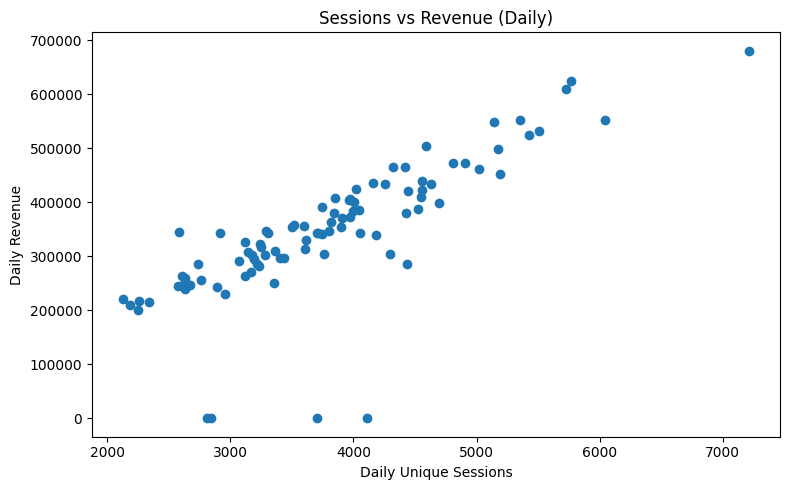

Pearson correlation: 0.791
P-value: 6.483532312080735e-21


In [ ]:
# --- Daily sessions and revenue ---
daily_metrics = (
    df.groupby("order_date")
      .agg(
          sessions=("ga_session_id", "nunique"),
          revenue=("revenue", "sum")
      )
      .sort_index()
)

# --- Scatter plot: sessions vs revenue ---
plt.figure(figsize=(8, 5))
plt.scatter(daily_metrics["sessions"], daily_metrics["revenue"])
plt.title("Sessions vs Revenue (Daily)")
plt.xlabel("Daily Unique Sessions")
plt.ylabel("Daily Revenue")
plt.tight_layout()
plt.show()

# --- Pearson correlation + p-value ---
corr, p_value = stats.pearsonr(daily_metrics["sessions"], daily_metrics["revenue"])

print("Pearson correlation:", round(corr, 3))
print("P-value:", p_value)

In [ ]:
print(df.columns)

Index(['order_date', 'ga_session_id', 'continent', 'country', 'device',
       'browser', 'mobile_model_name', 'operating_system', 'language',
       'traffic_source_info', 'traffic_channel', 'registered_user_id',
       'is_email_verified', 'is_subscribed', 'category', 'product_name',
       'price', 'short_description', 'revenue', 'weekday'],
      dtype='object')


#### **Insight**

The Pearson correlation coefficient between daily sessions and daily revenue equals **0.79**, indicating a strong positive relationship between website traffic and sales.

This means that days with higher numbers of user sessions tend to generate higher revenue.

The p-value is significantly below the standard significance threshold (p < 0.05), which indicates that the observed relationship is statistically significant and unlikely to occur by random chance.

Overall, the analysis confirms that website traffic is a key driver of revenue generation.

A few observations with zero revenue despite a moderate number of sessions may indicate days with no completed purchases or possible data recording issues.

### **7.2 Revenue Correlation Between Continents**

We analyze whether revenue trends across major continents move together over time.

In [ ]:
# Revenue per continent per day
continent_revenue = pd.pivot_table(
    df,
    values="revenue",
    index="order_date",
    columns="continent",
    aggfunc="sum"
)

# Top 3 continents by revenue
top_continents = (
    continent_revenue.sum()
    .sort_values(ascending=False)
    .head(3)
    .index
)

continent_revenue = continent_revenue[top_continents]

# Correlation matrix
continent_corr = continent_revenue.corr()

display(continent_corr.round(2))

continent,Americas,Asia,Europe
continent,,,
Americas,1.00,0.79,0.77
Asia,0.79,1.00,0.77
Europe,0.77,0.77,1.00


In [ ]:
# Statistical significance test
for i in range(len(top_continents)):
    for j in range(i + 1, len(top_continents)):
        c1 = top_continents[i]
        c2 = top_continents[j]

        corr, p = stats.pearsonr(
            continent_revenue[c1],
            continent_revenue[c2]
        )

        print(f"{c1} vs {c2}: correlation = {corr:.3f}, p-value = {p:.5f}")

Americas vs Asia: correlation = 0.792, p-value = 0.00000
Americas vs Europe: correlation = 0.771, p-value = 0.00000
Asia vs Europe: correlation = 0.768, p-value = 0.00000


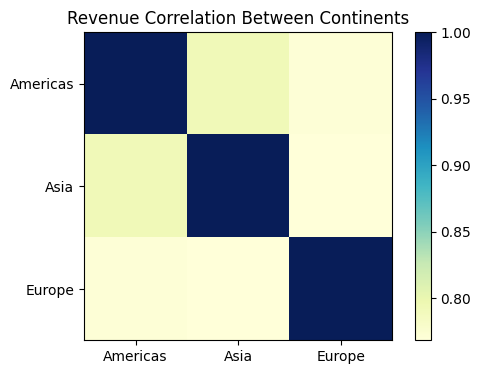

In [ ]:
plt.figure(figsize=(6,4))
plt.imshow(continent_corr, cmap="YlGnBu")

plt.xticks(range(len(continent_corr)), continent_corr.columns)
plt.yticks(range(len(continent_corr)), continent_corr.columns)

plt.title("Revenue Correlation Between Continents")

plt.colorbar()
plt.show()

#### **Insight**

The analysis shows a strong positive correlation between daily revenue trends across the top three continents: the Americas, Asia, and Europe.

Correlation coefficients range from **0.77 to 0.79**, indicating that sales patterns across these regions move closely together over time.

The p-values are extremely small (p < 0.05), confirming that the observed relationships are statistically significant.

This suggests that global factors — such as overall demand trends, marketing campaigns, or seasonal effects — influence revenue across multiple regions simultaneously.

### **7.3 Revenue Correlation Between Traffic Channels**

To analyze whether revenue trends move together across different traffic acquisition channels, we examine the correlation of daily revenue between traffic channels.

This analysis helps determine whether fluctuations in revenue are driven by channel-specific factors or by broader demand trends that affect multiple channels simultaneously.

We calculate Pearson correlation coefficients and visualize the relationships using a correlation heatmap.

In [ ]:
# Revenue per traffic channel per day
channel_revenue = pd.pivot_table(
    df,
    values="revenue",
    index="order_date",
    columns="traffic_channel",
    aggfunc="sum"
)

# Correlation matrix
channel_corr = channel_revenue.corr()

display(channel_corr.round(2))

traffic_channel,Direct,Organic Search,Paid Search,Social Search,Undefined
traffic_channel,,,,,
Direct,1.00,0.84,0.81,0.60,0.52
Organic Search,0.84,1.00,0.87,0.58,0.53
Paid Search,0.81,0.87,1.00,0.60,0.52
Social Search,0.60,0.58,0.60,1.00,0.46
Undefined,0.52,0.53,0.52,0.46,1.00


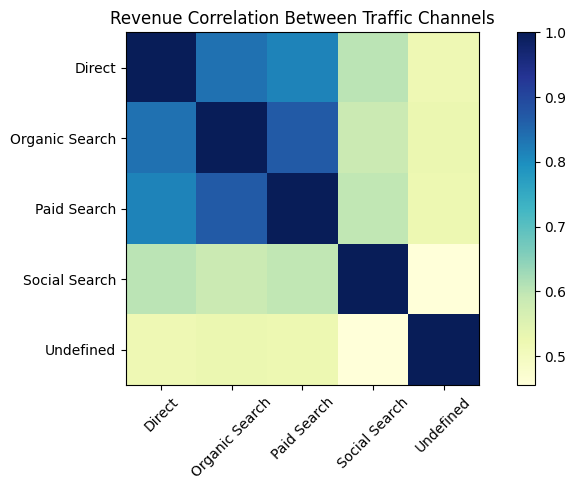

In [ ]:
plt.figure(figsize=(8,5))

plt.imshow(channel_corr, cmap="YlGnBu")

plt.xticks(range(len(channel_corr.columns)), channel_corr.columns, rotation=45)
plt.yticks(range(len(channel_corr.columns)), channel_corr.columns)

plt.title("Revenue Correlation Between Traffic Channels")

plt.colorbar()

plt.tight_layout()
plt.show()

In [ ]:
channels = channel_revenue.columns

for i in range(len(channels)):
    for j in range(i+1, len(channels)):
        c1 = channels[i]
        c2 = channels[j]

        corr, p = stats.pearsonr(
            channel_revenue[c1],
            channel_revenue[c2]
        )

        print(f"{c1} vs {c2}: correlation = {corr:.3f}, p-value = {p:.5f}")

Direct vs Organic Search: correlation = 0.838, p-value = 0.00000
Direct vs Paid Search: correlation = 0.814, p-value = 0.00000
Direct vs Social Search: correlation = 0.604, p-value = 0.00000
Direct vs Undefined: correlation = 0.518, p-value = 0.00000
Organic Search vs Paid Search: correlation = 0.870, p-value = 0.00000
Organic Search vs Social Search: correlation = 0.583, p-value = 0.00000
Organic Search vs Undefined: correlation = 0.526, p-value = 0.00000
Paid Search vs Social Search: correlation = 0.596, p-value = 0.00000
Paid Search vs Undefined: correlation = 0.522, p-value = 0.00000
Social Search vs Undefined: correlation = 0.455, p-value = 0.00001


#### **Insight**

The correlation analysis reveals strong positive relationships between revenue generated by major traffic channels.

The highest correlations are observed between **Organic Search**, **Paid Search**, and **Direct** traffic, with coefficients ranging from **0.81 to 0.87**. This indicates that revenue trends across these channels tend to move together over time.

Revenue from **Social Search** shows moderate correlations with other channels (around **0.58–0.60**), suggesting that it follows overall demand trends but may also be influenced by channel-specific factors.

The **Undefined** traffic channel demonstrates weaker correlations with other channels, indicating more irregular or less predictable revenue patterns.

All observed relationships are statistically significant (p < 0.05), confirming that the correlations are unlikely to occur by random chance.

Overall, the results suggest that revenue dynamics are largely driven by broader market demand and seasonality rather than isolated changes within individual traffic channels.

### **7.4 Revenue Correlation Between Product Categories**

To understand whether revenue trends move together across different product categories, we analyze the correlation of daily revenue between the top product categories.

This analysis helps determine whether fluctuations in sales are driven by overall market demand or by category-specific factors.

We focus on the top five product categories by total revenue and calculate Pearson correlation coefficients between their daily revenue values.

In [ ]:
top_categories = (
    df.groupby("category")["revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(5)
      .index
)

category_revenue = pd.pivot_table(
    df[df["category"].isin(top_categories)],
    values="revenue",
    index="order_date",
    columns="category",
    aggfunc="sum"
)
category_corr = category_revenue.corr()

display(category_corr.round(2))

category,Beds,Bookcases & shelving units,Cabinets & cupboards,Chairs,Sofas & armchairs
category,,,,,
Beds,1.00,0.59,0.51,0.55,0.54
Bookcases & shelving units,0.59,1.00,0.54,0.64,0.67
Cabinets & cupboards,0.51,0.54,1.00,0.57,0.66
Chairs,0.55,0.64,0.57,1.00,0.58
Sofas & armchairs,0.54,0.67,0.66,0.58,1.00


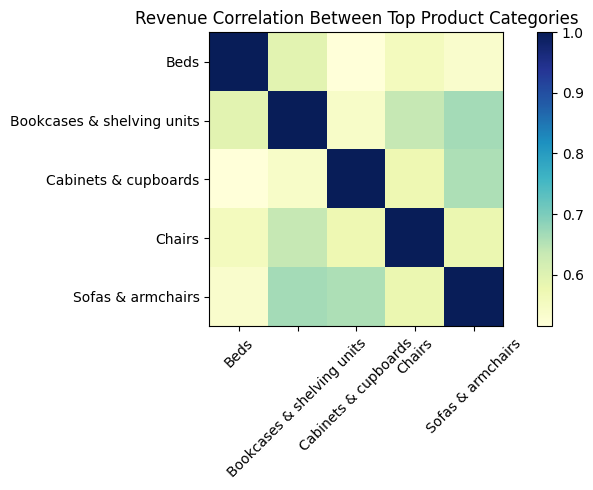

In [ ]:
plt.figure(figsize=(8,5))

plt.imshow(category_corr, cmap="YlGnBu")

plt.xticks(range(len(category_corr.columns)), category_corr.columns, rotation=45)
plt.yticks(range(len(category_corr.columns)), category_corr.columns)

plt.title("Revenue Correlation Between Top Product Categories")

plt.colorbar()

plt.tight_layout()
plt.show()

In [ ]:
cats = category_revenue.columns

for i in range(len(cats)):
    for j in range(i+1, len(cats)):
        c1 = cats[i]
        c2 = cats[j]

        corr, p = stats.pearsonr(
            category_revenue[c1],
            category_revenue[c2]
        )

        print(f"{c1} vs {c2}: correlation = {corr:.3f}, p-value = {p:.5f}")

Beds vs Bookcases & shelving units: correlation = 0.593, p-value = 0.00000
Beds vs Cabinets & cupboards: correlation = 0.515, p-value = 0.00000
Beds vs Chairs: correlation = 0.554, p-value = 0.00000
Beds vs Sofas & armchairs: correlation = 0.535, p-value = 0.00000
Bookcases & shelving units vs Cabinets & cupboards: correlation = 0.539, p-value = 0.00000
Bookcases & shelving units vs Chairs: correlation = 0.637, p-value = 0.00000
Bookcases & shelving units vs Sofas & armchairs: correlation = 0.666, p-value = 0.00000
Cabinets & cupboards vs Chairs: correlation = 0.573, p-value = 0.00000
Cabinets & cupboards vs Sofas & armchairs: correlation = 0.658, p-value = 0.00000
Chairs vs Sofas & armchairs: correlation = 0.578, p-value = 0.00000


#### **Insight**

The correlation analysis reveals moderate positive relationships between revenue trends across the top product categories.

Correlation coefficients range from approximately **0.51 to 0.67**, indicating that sales across these categories tend to move in the same direction over time.

This suggests that revenue fluctuations are influenced by broader market demand and seasonal patterns rather than by isolated category-specific factors.

All observed relationships are statistically significant (p < 0.05), confirming that the correlations are unlikely to occur by random chance.

Overall, the results indicate that customer demand for major furniture categories tends to increase or decrease simultaneously.

### **7.5 Relationship Between Device Revenue Trends**

To explore whether revenue patterns differ across device types, we analyze the relationship between daily revenue generated by desktop, mobile, and tablet devices.

Understanding these relationships helps determine whether revenue fluctuations affect all device types simultaneously or whether certain devices behave differently over time.

We aggregate daily revenue by device type and calculate Pearson correlation coefficients between the revenue trends.

In [ ]:
device_revenue = pd.pivot_table(
    df,
    values="revenue",
    index="order_date",
    columns="device",
    aggfunc="sum"
)

device_revenue.corr()

device,desktop,mobile,tablet
device,,,
desktop,1.00,0.87,0.60
mobile,0.87,1.00,0.57
tablet,0.60,0.57,1.00


#### **Insight**

The correlation analysis shows strong positive relationships between revenue trends for desktop and mobile devices (correlation ≈ 0.87).

This indicates that revenue fluctuations on desktop and mobile platforms tend to occur simultaneously, suggesting similar user behavior patterns across these devices.

Tablet revenue demonstrates a weaker correlation with both desktop and mobile (0.57–0.60), likely due to its smaller share of total traffic and purchases.

Overall, the results suggest that desktop and mobile devices drive the majority of revenue dynamics, while tablet usage plays a more minor role.

## **8. Statistical Analysis of Differences Between Groups**

### **8.1 Revenue Comparison: Registered vs Non-Registered Users**

To determine whether registered users generate different revenue compared to non-registered users, we analyze daily revenue generated by both groups.

First, we aggregate revenue per day for each group.  
Then we analyze the distribution of revenue values and apply an appropriate statistical test to evaluate whether the observed differences are statistically significant.

is_registered,non_registered,registered
order_date,,
2020-11-01,222745.50,21547.00
2020-11-02,310550.00,44956.80
2020-11-03,469829.10,29150.50
2020-11-04,318204.90,20982.20
2020-11-05,365942.00,25334.60


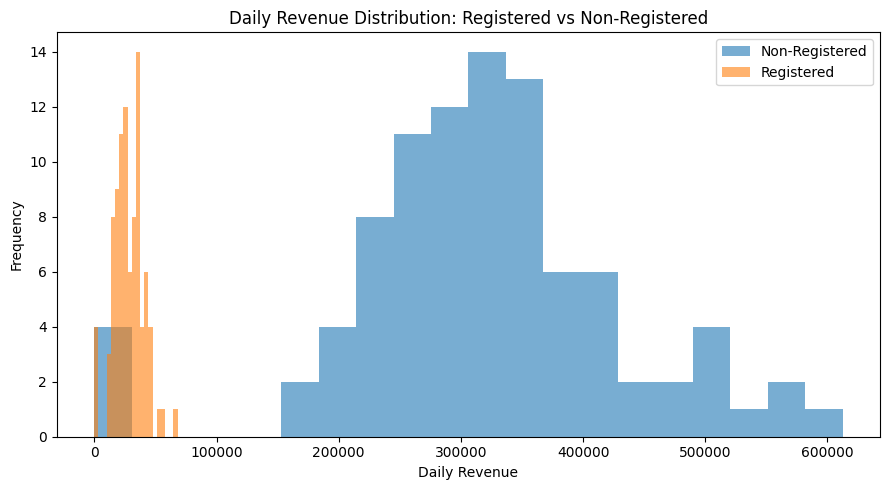

Welch t-test results
t-statistic: -24.428
p-value: 0.000000

Mann–Whitney U test results
U-statistic: 360.0
p-value: 0.000000


In [ ]:
# --- 1) Create a binary flag for registration ---
# If registered_user_id is present -> registered user, otherwise -> non-registered user
df["is_registered"] = np.where(df["registered_user_id"].notna(), 1, 0)

# --- 2) Aggregate daily revenue for each group ---
# We sum revenue per day separately for registered and non-registered users
daily_rev_by_group = (
    df.groupby(["order_date", "is_registered"])["revenue"]
      .sum()
      .reset_index()
)

# --- 3) Convert to a 2-column wide table (registered vs non_registered) ---
revenue_by_user = daily_rev_by_group.pivot(
    index="order_date",
    columns="is_registered",
    values="revenue"
).fillna(0)

# Rename columns for readability
revenue_by_user = revenue_by_user.rename(columns={0: "non_registered", 1: "registered"})

# Quick check
display(revenue_by_user.head())

# --- 4) Visualize distributions (daily revenue) ---
plt.figure(figsize=(9,5))

plt.hist(revenue_by_user["non_registered"], bins=20, alpha=0.6, label="Non-Registered")
plt.hist(revenue_by_user["registered"], bins=20, alpha=0.6, label="Registered")

plt.title("Daily Revenue Distribution: Registered vs Non-Registered")
plt.xlabel("Daily Revenue")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

# --- 5) Statistical test (Welch's t-test) ---
# Welch's t-test is more robust when variances are not assumed equal
t_stat, p_value = stats.ttest_ind(
    revenue_by_user["registered"],
    revenue_by_user["non_registered"],
    equal_var=False
)

print("Welch t-test results")
print("t-statistic:", round(t_stat, 3))
print("p-value:", f"{p_value:.6f}")

# --- 6) Optional: Non-parametric test (Mann–Whitney U) ---
# Useful if distributions are non-normal / heavy-tailed
u_stat, p_mw = stats.mannwhitneyu(
    revenue_by_user["registered"],
    revenue_by_user["non_registered"],
    alternative="two-sided"
)

print("\nMann–Whitney U test results")
print("U-statistic:", round(u_stat, 3))
print("p-value:", f"{p_mw:.6f}")

#### **Insight**

The analysis compares daily revenue generated by registered and non-registered users.

The distribution of daily revenue shows that non-registered users generate significantly higher total revenue per day compared to registered users. This is expected because the number of non-registered sessions is substantially larger.

The Welch t-test results indicate a statistically significant difference between the two groups (t = -24.43, p < 0.001). The Mann–Whitney U test confirms the same conclusion using a non-parametric approach.

Since both tests produce extremely small p-values, we reject the null hypothesis and conclude that the difference in revenue between registered and non-registered users is statistically significant.

However, this difference likely reflects differences in user volume rather than individual purchasing behavior.

Future analysis could compare revenue per session or revenue per user to better understand whether registered users are individually more valuable customers.

### **8.2 Sessions Across Traffic Channels**

Next, we analyze whether the number of sessions differs significantly across traffic channels.

Daily session counts are aggregated for each traffic channel.  
To compare multiple independent groups, we apply a **one-way ANOVA test**.

Additionally, since session distributions may not be normally distributed, we also apply a **Kruskal–Wallis test**, which is a non-parametric alternative to ANOVA.

These tests help determine whether traffic channels generate statistically different levels of user activity.

traffic_channel,Direct,Organic Search,Paid Search,Social Search,Undefined
order_date,,,,,
2020-11-01,608,920,706,214,128
2020-11-02,810,1242,970,315,262
2020-11-03,1216,1871,1367,392,327
2020-11-04,935,1425,1145,368,311
2020-11-05,845,1293,917,346,342


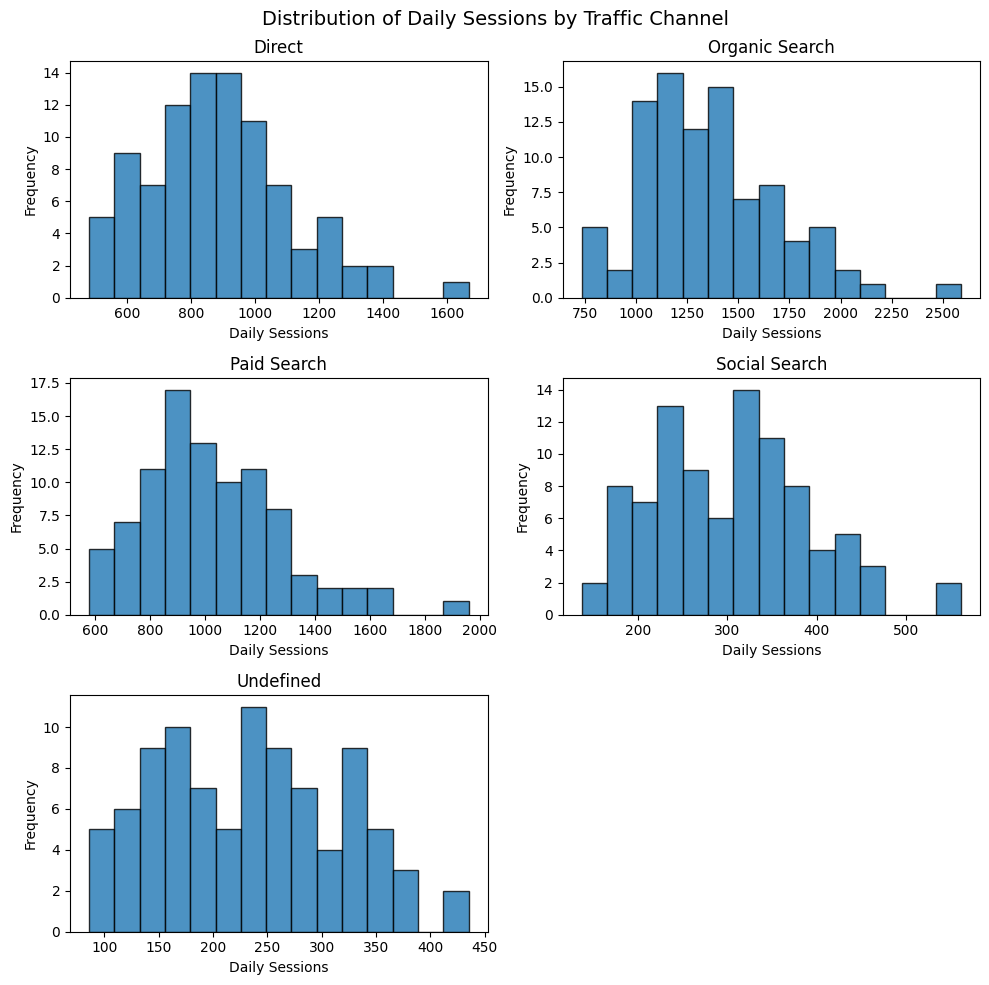

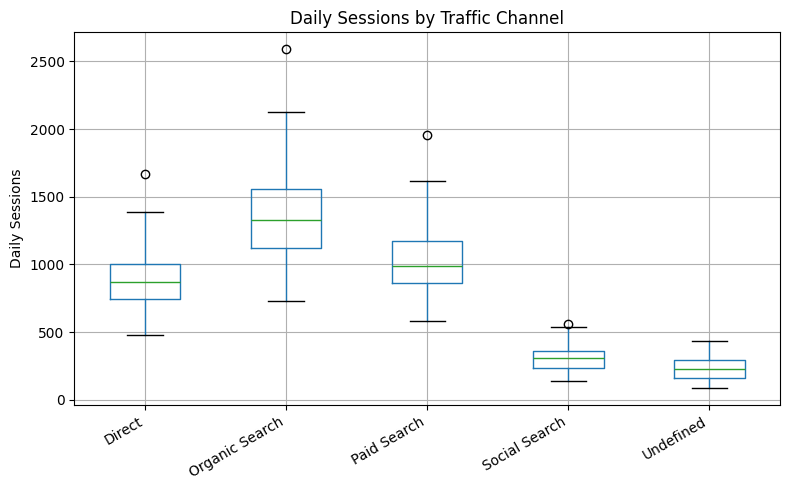


Average Daily Sessions by Traffic Channel


,Average Daily Sessions
traffic_channel,
Organic Search,1352.45
Paid Search,1025.45
Direct,884.59
Social Search,303.41
Undefined,233.51



ANOVA Test Results
------------------
F-statistic: 439.768
p-value: 0.000000

Kruskal–Wallis Test Results
---------------------------
H-statistic: 368.981
p-value: 0.000000


In [ ]:
# --------------------------------------------
# 0. Safety: make sure no missing values
# --------------------------------------------
# Daily sessions by traffic channel
sessions_by_channel = (
    df.groupby(["order_date", "traffic_channel"])["ga_session_id"]
      .nunique()
      .unstack()
)

display(sessions_by_channel.head())

sessions_by_channel = sessions_by_channel.fillna(0)

# --------------------------------------------
# 1. Prepare samples for statistical tests
# --------------------------------------------
channels = sessions_by_channel.columns.tolist()
samples = [sessions_by_channel[ch].values for ch in channels]

# --------------------------------------------
# 2. Visualize distribution of daily sessions (histograms)
# --------------------------------------------
fig, axes = plt.subplots(3, 2, figsize=(10, 10))
axes = axes.flatten()

for i, channel in enumerate(channels):
    axes[i].hist(
        sessions_by_channel[channel],
        bins=15,
        edgecolor="black",
        alpha=0.8
    )
    axes[i].set_title(channel)
    axes[i].set_xlabel("Daily Sessions")
    axes[i].set_ylabel("Frequency")

# Remove empty subplot
for j in range(len(channels), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Distribution of Daily Sessions by Traffic Channel", fontsize=14)
plt.tight_layout()
plt.show()

# --------------------------------------------
# 2.1 Visualize distribution (boxplot)
# --------------------------------------------
plt.figure(figsize=(8, 5))
sessions_by_channel.boxplot()
plt.title("Daily Sessions by Traffic Channel")
plt.ylabel("Daily Sessions")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# --------------------------------------------
# 3. Average sessions per channel
# --------------------------------------------
print("\nAverage Daily Sessions by Traffic Channel")

display(
    sessions_by_channel.mean()
    .sort_values(ascending=False)
    .to_frame(name="Average Daily Sessions")
)

# --------------------------------------------
# 4. One-way ANOVA test
# --------------------------------------------
anova_stat, anova_p = stats.f_oneway(*samples)

print("\nANOVA Test Results")
print("------------------")
print("F-statistic:", round(anova_stat, 3))
print("p-value:", f"{anova_p:.6f}")

# --------------------------------------------
# 5. Kruskal–Wallis test (non-parametric)
# --------------------------------------------
kw_stat, kw_p = stats.kruskal(*samples)

print("\nKruskal–Wallis Test Results")
print("---------------------------")
print("H-statistic:", round(kw_stat, 3))
print("p-value:", f"{kw_p:.6f}")

#### **Insight**

The analysis shows clear differences in daily session volumes across traffic channels.

Organic Search generates the highest average number of daily sessions (≈1352), followed by Paid Search (≈1025) and Direct traffic (≈885). In contrast, Social Search (≈303) and Undefined traffic (≈234) contribute significantly fewer sessions on average.

To test whether these differences are statistically significant, we applied both a one-way ANOVA test and a Kruskal–Wallis test.

Both tests produced extremely small p-values (p < 0.001), allowing us to reject the null hypothesis that all channels have the same average session volume.

This indicates that traffic channels generate statistically different levels of user activity, likely reflecting differences in acquisition strategies, marketing investment, and user behavior across channels.

### **8.3 Organic Traffic Share: Europe vs Americas**

In this section we compare the share of organic traffic sessions between Europe and the Americas.

We test whether the proportion of sessions coming from Organic Search differs significantly between the two regions.

To evaluate this difference we apply a **two-proportion z-test**, which is commonly used to compare proportions between two independent groups.

Europe organic sessions: 23195
Americas organic sessions: 68671

Europe total sessions: 65135
Americas total sessions: 193179

Organic traffic share
----------------------
Europe: 0.3561
Americas: 0.3555

Two-Proportion Z-Test Results
-----------------------------
Z-statistic: 0.29
p-value: 0.772188


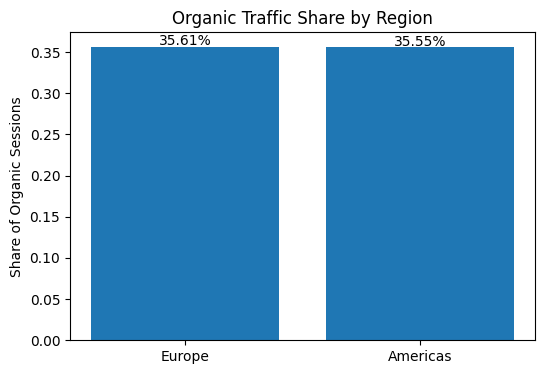

In [ ]:
# Filter sessions for the two regions
eu_sessions = df[df["continent"] == "Europe"]
us_sessions = df[df["continent"] == "Americas"]

# Organic sessions
organic_eu = eu_sessions[eu_sessions["traffic_channel"] == "Organic Search"]["ga_session_id"].nunique()
organic_us = us_sessions[us_sessions["traffic_channel"] == "Organic Search"]["ga_session_id"].nunique()

# Total sessions
total_eu = eu_sessions["ga_session_id"].nunique()
total_us = us_sessions["ga_session_id"].nunique()

print("Europe organic sessions:", organic_eu)
print("Americas organic sessions:", organic_us)

print("\nEurope total sessions:", total_eu)
print("Americas total sessions:", total_us)

share_eu = organic_eu / total_eu
share_us = organic_us / total_us

print("\nOrganic traffic share")
print("----------------------")
print("Europe:", round(share_eu, 4))
print("Americas:", round(share_us, 4))

# Counts of successes
counts = [organic_eu, organic_us]

# Number of observations
nobs = [total_eu, total_us]

z_stat, p_value = proportions_ztest(counts, nobs)

print("\nTwo-Proportion Z-Test Results")
print("-----------------------------")
print("Z-statistic:", round(z_stat, 3))
print("p-value:", f"{p_value:.6f}")

shares = [share_eu, share_us]
regions = ["Europe", "Americas"]

plt.figure(figsize=(6,4))

bars = plt.bar(regions, shares)

plt.title("Organic Traffic Share by Region")
plt.ylabel("Share of Organic Sessions")

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y + 0.002, f"{y:.2%}", ha="center")

plt.show()

#### **Insight**

The analysis compares the share of organic traffic sessions between Europe and the Americas.

The calculated proportions are very similar: approximately **35.6% in Europe** and **35.5% in the Americas**.

To evaluate whether this difference is statistically significant, we applied a **two-proportion z-test**.

The test produced a **p-value of 0.772**, which is well above the standard significance threshold of 0.05. Therefore, we fail to reject the null hypothesis.

This indicates that there is **no statistically significant difference** in the share of organic traffic between Europe and the Americas. In practical terms, both regions rely on organic search to a very similar extent.

### **8.4 Additional Statistical Tests**

To further validate our analysis, we apply several additional statistical tests that are commonly used in exploratory data analysis.

These tests help evaluate assumptions about the data distribution, compare variances between groups, and verify the statistical significance of relationships between variables.

In [ ]:
# --------------------------------------------
# Normality test (Shapiro–Wilk)
# --------------------------------------------

stat, p = stats.shapiro(revenue_by_user["registered"])

print("Shapiro-Wilk Test (Registered Users Revenue)")
print("--------------------------------------------")
print("Statistic:", round(stat,3))
print("p-value:", f"{p:.6f}")

# --------------------------------------------
# Variance equality test (Levene)
# --------------------------------------------

stat, p = stats.levene(
    revenue_by_user["registered"],
    revenue_by_user["non_registered"]
)

print("\nLevene Test Results")
print("-------------------")
print("Statistic:", round(stat,3))
print("p-value:", f"{p:.6f}")

# --------------------------------------------
# Correlation significance test
# --------------------------------------------

corr, p = stats.pearsonr(
    daily_metrics["sessions"],
    daily_metrics["revenue"]
)

print("\nPearson Correlation Significance Test")
print("-------------------------------------")
print("Correlation:", round(corr,3))
print("p-value:", f"{p:.6f}")

Shapiro-Wilk Test (Registered Users Revenue)
--------------------------------------------
Statistic: 0.979
p-value: 0.148167

Levene Test Results
-------------------
Statistic: 75.529
p-value: 0.000000

Pearson Correlation Significance Test
-------------------------------------
Correlation: 0.791
p-value: 0.000000


#### **Insight**

Several additional statistical tests were conducted to validate the robustness of the analysis.

The **Shapiro–Wilk test** was applied to evaluate whether the distribution of daily revenue from registered users follows a normal distribution.  
The test produced a p-value of **0.148**, which is greater than the standard significance level of 0.05. Therefore, we fail to reject the null hypothesis and conclude that the distribution does not significantly deviate from normality.

Next, the **Levene test** was used to check whether the variances of revenue between registered and non-registered users are equal.  
The test returned a p-value close to **0.000**, indicating that the variances between the two groups are statistically different.

Finally, the **Pearson correlation significance test** was performed to evaluate the relationship between daily sessions and revenue.  
The correlation coefficient is **0.791**, indicating a strong positive relationship between traffic volume and revenue.  
The p-value is extremely small (p < 0.001), confirming that the observed correlation is statistically significant.

Overall, these additional tests strengthen the validity of the statistical conclusions obtained throughout the analysis.

## **9 Key Business Insights**

Based on the exploratory data analysis and statistical tests performed in this project, several key insights about the business performance and user behavior were identified.

### **1. Website traffic strongly drives revenue**

A strong positive correlation was observed between the number of daily sessions and total revenue (Pearson correlation = **0.79**, p < 0.001).  
This indicates that increases in website traffic are closely associated with higher sales volume.

From a business perspective, this suggests that investments in marketing and traffic acquisition can have a significant impact on overall revenue.

---

### **2. Organic search is the most important traffic source**

Among all traffic channels, **Organic Search generates the highest average number of daily sessions**, significantly outperforming other channels.

Statistical tests (ANOVA and Kruskal–Wallis) confirm that the differences in traffic volumes between channels are **statistically significant**.

This suggests that search engine visibility and SEO performance play a critical role in driving user acquisition.

---

### **3. Registered users behave differently from non-registered users**

Revenue distributions between registered and non-registered users differ significantly, as confirmed by statistical tests (Welch t-test and Mann–Whitney U test).

This indicates that user registration status is associated with different purchasing behavior and spending patterns.

For the business, this suggests that improving user registration and engagement strategies could influence overall revenue performance.

---

### **4. Sales trends are consistent across regions and categories**

Revenue correlations across continents and product categories are generally **moderate to strong**, indicating that sales fluctuations are driven largely by overall market demand rather than isolated regional or product-specific factors.

This suggests that macro trends (seasonality, promotions, demand cycles) affect multiple segments simultaneously.

---

### **5. Device usage patterns show similar revenue dynamics**

Revenue trends across **desktop and mobile devices** are highly correlated, suggesting that user demand evolves similarly across platforms.

However, slightly weaker correlations with tablets indicate that tablet usage may represent a smaller or more specialized segment of users.

---

### **Overall conclusion**

The analysis demonstrates that traffic volume, acquisition channels, and user characteristics all play important roles in shaping sales performance.

In particular, organic traffic and overall website sessions appear to be the most influential drivers of revenue, while user registration status and device usage patterns provide additional insights into customer behavior.

These findings can help guide marketing strategies, platform optimization, and user engagement initiatives aimed at improving overall business performance.

## **10. Tableau Dashboard**

To complement the exploratory and statistical analysis, an interactive dashboard was created using **Tableau Public**.

The dashboard summarizes key business metrics and allows users to explore sales performance across different dimensions such as traffic channels, regions, product categories, and time.

The dashboard consists of **two pages**, each designed to answer specific business questions.

---

### **Page 1 — Sales Overview**

This page provides a high-level overview of the company's performance.

Main visualizations include:

- **Revenue trend over time**
- **Revenue by continent**
- **Revenue by product category**
- **Sessions vs Revenue relationship**
- **Key KPI indicators (Total Revenue, Total Sessions)**

The purpose of this page is to quickly understand the overall performance of the business and identify major trends in revenue and traffic.

---

### **Page 2 — Traffic and Customer Behavior**

This page focuses on user acquisition and behavior patterns.

Main visualizations include:

- **Sessions by traffic channel**
- **Revenue by traffic channel**
- **Device usage distribution**
- **Registered vs Non-registered user revenue comparison**

Interactive filters allow users to explore the data by:

- **Date**
- **Continent**
- **Traffic channel**
- **Product category**
- **Device type**

This page helps analyze how users arrive at the platform and how their behavior impacts sales.

---

### **Dashboard Link**

The interactive dashboard is available on Tableau Public:

**[Tableau Public Dashboard](https://public.tableau.com/views/PortfolioProject1_17727109855070/Dashboard1-SalesOverview?:language=en-US&publish=yes&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link)**

### **10.1 Prepare dataset for Tableau**

In this section, we prepare a clean dataset for Tableau by selecting the required fields, ensuring correct data types, and exporting the dataset to a CSV file.


In [ ]:
# Ensure correct data types for Tableau export

# 1) Datetime
df["order_date"] = pd.to_datetime(df["order_date"])

# 2) Numeric fields (safe conversion)
df["price"] = pd.to_numeric(df["price"], errors="coerce")
df["revenue"] = pd.to_numeric(df["revenue"], errors="coerce")

# 3) Optional: make boolean-like flags clearer (0/1/NaN)
for col in ["is_email_verified", "is_subscribed"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Quick check
display(df.head(3))
print("Rows, columns:", df.shape)
print("Date range:", df["order_date"].min().date(), "→", df["order_date"].max().date())

,order_date,ga_session_id,continent,country,device,browser,mobile_model_name,operating_system,language,traffic_source_info,traffic_channel,registered_user_id,is_email_verified,is_subscribed,category,product_name,price,short_description,revenue,weekday,is_registered
0,2020-11-01,5760483956,Americas,United States,desktop,Chrome,Safari,Macintosh,zh,<Other> / <Other>,Paid Search,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.00,"Shelving unit with laptop table, 202x36x175 cm",609.00,Sunday,0
1,2020-11-01,7115337200,Europe,United Kingdom,desktop,Chrome,Chrome,Web,en-us,(organic) / organic,Organic Search,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.00,"Shelving unit with laptop table, 202x36x175 cm",609.00,Sunday,0
2,2020-11-01,3978035233,Europe,Norway,mobile,Chrome,<Other>,Web,zh,(direct) / (none),Direct,<NA>,<NA>,<NA>,Tables & desks,RÅSKOG,189.00,"Trolley, 35x45x78 cm",189.00,Sunday,0


Rows, columns: (349545, 21)
Date range: 2020-11-01 → 2021-01-31


### **10.2 Export dataset to CSV**

The dataset is exported to a CSV file and will be used as the data source in Tableau Public.

In [ ]:
# Export to CSV for Tableau
output_path = "ecommerce_sales_dataset_for_tableau.csv"
df.to_csv(output_path, index=False)

print("Saved file:", output_path)

Saved file: ecommerce_sales_dataset_for_tableau.csv
